# DATATHON 2026 - Phase 2 EDA Storytelling

Notebook nay bat dau [EXECUTE MODE] cho **Phase A (Semantic Layer)** va **Level 1 (Descriptive Baseline Pulse)**.

Muc tieu: chuan hoa metric tren DuckDB, ve cac bieu do baseline theo phong cach corporate, va dat nen cho 3 tang tiep theo (Diagnostic, Predictive, Prescriptive).

## Phase A - Setup, Style, va Ket noi du lieu

In [2]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from IPython.display import display

# Corporate minimalist palette
NAVY = '#0B1F3A'
BLUE = '#1F4E79'
TEAL = '#2A6F97'
CORAL = '#E76F51'
RED = '#C1121F'
GRAY = '#6B7280'
LIGHT_BG = '#F8FAFC'

sns.set_theme(style='whitegrid')
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.edgecolor': '#D1D5DB',
    'axes.labelcolor': '#111827',
    'axes.titleweight': 'bold',
    'axes.titlesize': 12,
    'axes.labelsize': 10,
    'xtick.color': '#374151',
    'ytick.color': '#374151',
    'grid.color': '#E5E7EB',
    'grid.linestyle': '-',
    'grid.linewidth': 0.8,
    'font.size': 10
})

def style_axis(ax, title=None, xlabel=None, ylabel=None):
    if title is not None:
        ax.set_title(title, color=NAVY, pad=10)
    if xlabel is not None:
        ax.set_xlabel(xlabel)
    if ylabel is not None:
        ax.set_ylabel(ylabel)
    sns.despine(ax=ax, top=True, right=True)

In [3]:
DB_PATH = Path('gridbreaker.duckdb')
assert DB_PATH.exists(), f'Khong tim thay DB: {DB_PATH}'

con = duckdb.connect(str(DB_PATH))

source_tables = [
    'customers', 'geography', 'inventory', 'order_items', 'orders',
    'payments', 'products', 'promotions', 'returns', 'reviews',
    'sales', 'sample_submission', 'shipments', 'web_traffic'
]

table_df = con.execute('''
    SELECT table_name
    FROM information_schema.tables
    WHERE table_schema = 'main'
    ORDER BY table_name
''').df()

existing_tables = set(table_df['table_name'].tolist())
missing_tables = [t for t in source_tables if t not in existing_tables]
assert not missing_tables, f'Thieu bang trong DB: {missing_tables}'

print('Ket noi DuckDB thanh cong.')
print(f'So bang kiem tra: {len(source_tables)} / {len(source_tables)}')
display(table_df.head(20))

Ket noi DuckDB thanh cong.
So bang kiem tra: 14 / 14


,table_name
0,customers
1,geography
2,inventory
3,order_items
4,orders
5,payments
6,phase1_ingest_log
7,products
8,promotions
9,returns


In [4]:
# Semantic layer cho EDA
semantic_sql = '''
CREATE OR REPLACE VIEW v_order_items_dedup AS
SELECT DISTINCT
    order_id, product_id, quantity, unit_price, discount_amount, promo_id, promo_id_2
FROM order_items;

CREATE OR REPLACE VIEW v_daily_sales AS
SELECT
    CAST(Date AS DATE) AS date,
    Revenue AS revenue,
    COGS AS cogs,
    (Revenue - COGS) AS margin_abs,
    (Revenue - COGS) / NULLIF(Revenue, 0) AS margin_pct,
    CASE
        WHEN CAST(Date AS DATE) BETWEEN DATE '2020-03-01' AND DATE '2021-12-31' THEN 1
        ELSE 0
    END AS is_covid
FROM sales;

CREATE OR REPLACE VIEW v_line_finance AS
SELECT
    o.order_id,
    CAST(o.order_date AS DATE) AS order_date,
    lower(trim(o.order_status)) AS order_status,
    lower(trim(o.payment_method)) AS payment_method,
    o.order_source,
    o.device_type,
    g.region,
    oi.product_id,
    p.category,
    p.segment,
    p.size,
    oi.quantity,
    oi.unit_price,
    COALESCE(oi.discount_amount, 0) AS discount_amount,
    (oi.quantity * oi.unit_price) AS gross_line_revenue,
    (oi.quantity * oi.unit_price - COALESCE(oi.discount_amount, 0)) AS net_line_revenue,
    (oi.quantity * COALESCE(p.cogs, 0)) AS line_cogs,
    ((oi.quantity * oi.unit_price - COALESCE(oi.discount_amount, 0)) - (oi.quantity * COALESCE(p.cogs, 0))) AS line_margin
FROM orders o
INNER JOIN v_order_items_dedup oi ON o.order_id = oi.order_id
LEFT JOIN products p ON oi.product_id = p.product_id
LEFT JOIN geography g ON o.zip = g.zip;

CREATE OR REPLACE VIEW v_segment_category_profitability AS
SELECT
    segment,
    category,
    COUNT(DISTINCT order_id) AS n_orders,
    SUM(quantity) AS total_units,
    SUM(gross_line_revenue) AS gross_revenue,
    SUM(net_line_revenue) AS net_revenue,
    SUM(line_cogs) AS total_cogs,
    SUM(line_margin) AS margin_abs,
    SUM(line_margin) / NULLIF(SUM(net_line_revenue), 0) AS margin_pct
FROM v_line_finance
WHERE order_status NOT IN ('cancelled', 'returned')
GROUP BY segment, category;

CREATE OR REPLACE VIEW v_payment_status_consistency AS
WITH joined AS (
    SELECT
        o.order_id,
        lower(trim(o.payment_method)) AS payment_method_orders,
        lower(trim(p.payment_method)) AS payment_method_payments,
        lower(trim(o.order_status)) AS order_status
    FROM orders o
    INNER JOIN payments p ON o.order_id = p.order_id
)
SELECT
    COUNT(*) AS compared_rows,
    SUM(CASE WHEN payment_method_orders = payment_method_payments THEN 1 ELSE 0 END) AS matched_rows,
    SUM(CASE WHEN payment_method_orders <> payment_method_payments THEN 1 ELSE 0 END) AS mismatched_rows,
    SUM(CASE WHEN payment_method_orders = payment_method_payments THEN 1 ELSE 0 END) * 1.0 / COUNT(*) AS match_ratio
FROM joined;
'''

con.execute(semantic_sql)
print('Da tao semantic views cho Phase A.')

Da tao semantic views cho Phase A.


In [5]:
guardrail_df = con.execute('''
SELECT 'sales_missing_dates' AS check_name, CAST((
    WITH bounds AS (
        SELECT MIN(CAST(Date AS DATE)) AS min_date, MAX(CAST(Date AS DATE)) AS max_date FROM sales
    ), all_dates AS (
        SELECT * FROM generate_series((SELECT min_date FROM bounds), (SELECT max_date FROM bounds), INTERVAL 1 DAY) AS t(d)
    )
    SELECT COUNT(*)
    FROM all_dates a
    LEFT JOIN sales s ON CAST(s.Date AS DATE) = a.d
    WHERE s.Date IS NULL
) AS DOUBLE) AS value
UNION ALL
SELECT 'cogs_ge_price_violations' AS check_name, CAST(COUNT(*) AS DOUBLE) AS value
FROM products WHERE cogs >= price
UNION ALL
SELECT 'order_items_duplicate_natural_key' AS check_name, CAST(COUNT(*) AS DOUBLE) AS value
FROM (
    SELECT order_id, product_id, promo_id, promo_id_2
    FROM order_items
    GROUP BY order_id, product_id, promo_id, promo_id_2
    HAVING COUNT(*) > 1
) t
UNION ALL
SELECT 'payment_method_mismatch_rows' AS check_name, CAST(mismatched_rows AS DOUBLE) AS value
FROM v_payment_status_consistency
''').df()

display(guardrail_df)
assert float(guardrail_df.loc[guardrail_df['check_name'] == 'sales_missing_dates', 'value'].iloc[0]) == 0.0
assert float(guardrail_df.loc[guardrail_df['check_name'] == 'cogs_ge_price_violations', 'value'].iloc[0]) == 0.0
print('Guardrails pass cho Phase A baseline.')

,check_name,value
0,sales_missing_dates,0.0
1,cogs_ge_price_violations,0.0
2,order_items_duplicate_natural_key,16.0
3,payment_method_mismatch_rows,0.0


Guardrails pass cho Phase A baseline.


## Level 1 - Descriptive (The Baseline Pulse)
Muc tieu: tra loi cau hoi **What happened?** bang bo bieu do tong quan, khong ve chart roi rac.

In [6]:
daily_df = con.execute('SELECT * FROM v_daily_sales ORDER BY date').df()

monthly_df = con.execute('''
SELECT
    date_trunc('month', date) AS month,
    SUM(revenue) AS revenue,
    SUM(cogs) AS cogs,
    SUM(margin_abs) AS margin_abs,
    AVG(margin_pct) AS margin_pct,
    MAX(is_covid) AS is_covid
FROM v_daily_sales
GROUP BY 1
ORDER BY 1
''').df()

seasonality_df = con.execute('''
SELECT
    EXTRACT(year FROM date) AS year,
    EXTRACT(month FROM date) AS month,
    SUM(revenue) AS revenue
FROM v_daily_sales
GROUP BY 1, 2
ORDER BY 1, 2
''').df()

segment_df = con.execute('''
SELECT
    segment,
    SUM(net_revenue) AS net_revenue,
    SUM(margin_abs) AS margin_abs,
    SUM(margin_abs) / NULLIF(SUM(net_revenue), 0) AS margin_pct
FROM v_segment_category_profitability
GROUP BY segment
ORDER BY margin_pct DESC
''').df()

category_df = con.execute('''
SELECT
    category,
    SUM(net_revenue) AS net_revenue,
    SUM(margin_abs) AS margin_abs,
    SUM(margin_abs) / NULLIF(SUM(net_revenue), 0) AS margin_pct
FROM v_segment_category_profitability
GROUP BY category
ORDER BY net_revenue DESC
''').df()

display(daily_df.head())
display(segment_df.head())

,date,revenue,cogs,margin_abs,margin_pct,is_covid
0,2012-07-04,5123547.94,3982991.19,1140556.75,0.222611,0
1,2012-07-05,2751773.45,2150580.23,601193.22,0.218475,0
2,2012-07-06,3054029.42,2517632.84,536396.58,0.175636,0
3,2012-07-07,2667930.94,2108246.62,559684.32,0.209782,0
4,2012-07-08,2360851.90,1808622.79,552229.11,0.233911,0


,segment,net_revenue,margin_abs,margin_pct
0,Trendy,2.805772e+08,4.325281e+07,0.154157
1,Activewear,1.642321e+09,2.103319e+08,0.128070
2,Standard,1.944275e+08,2.462390e+07,0.126648
3,Everyday,4.390256e+09,4.531911e+08,0.103227
4,Balanced,4.177681e+09,3.666227e+08,0.087757


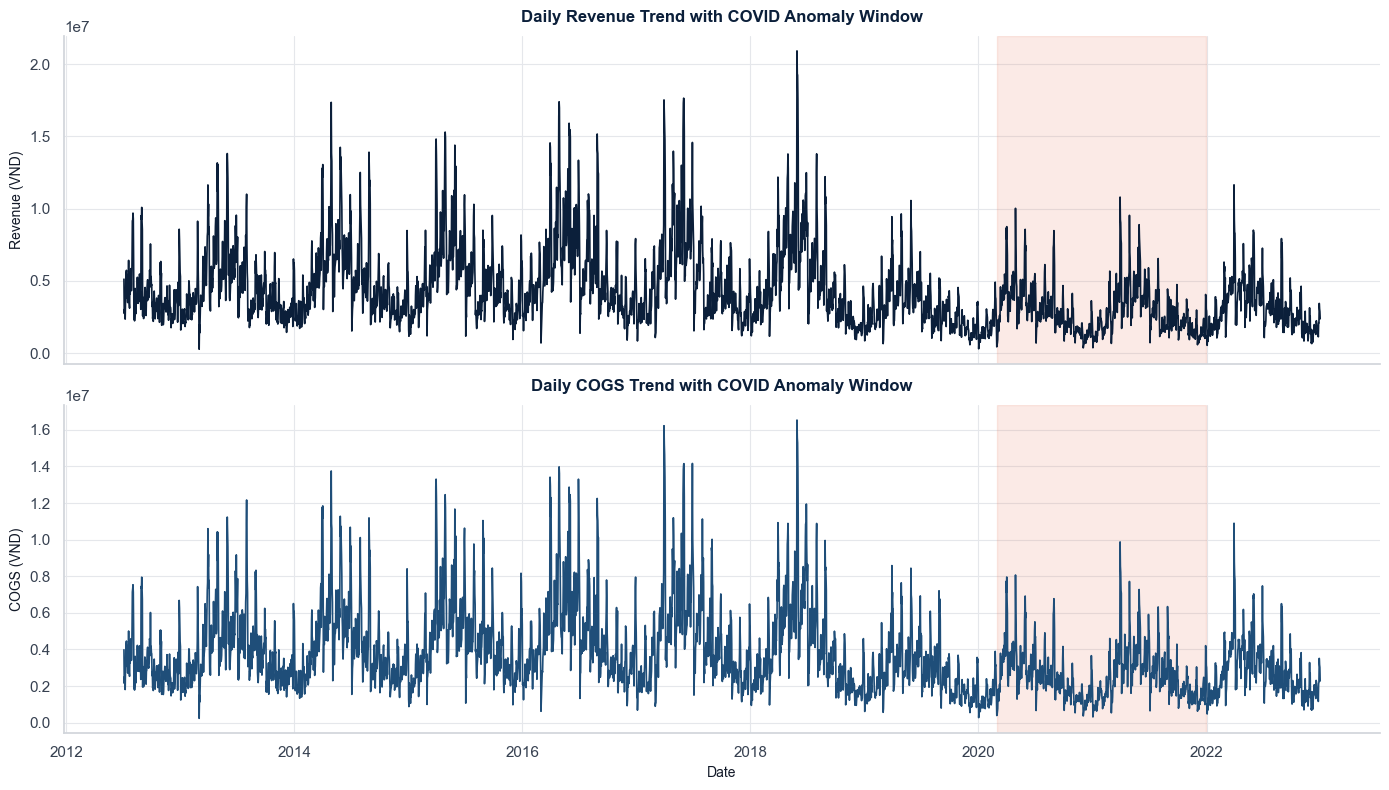

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(daily_df['date'], daily_df['revenue'], color=NAVY, linewidth=1.2)
axes[1].plot(daily_df['date'], daily_df['cogs'], color=BLUE, linewidth=1.2)

covid_start = pd.Timestamp('2020-03-01')
covid_end = pd.Timestamp('2021-12-31')
for ax in axes:
    ax.axvspan(covid_start, covid_end, color=CORAL, alpha=0.14)

style_axis(axes[0], 'Daily Revenue Trend with COVID Anomaly Window', '', 'Revenue (VND)')
style_axis(axes[1], 'Daily COGS Trend with COVID Anomaly Window', 'Date', 'COGS (VND)')

plt.tight_layout()
plt.show()

> **Business Insight (Level 1 - Macro Trend):**
> - Revenue va COGS co bien dong bat thuong trong cua so COVID, cho thay co **structural break** trong hanh vi mua sam.
> - Day la co so ky thuat de dua bien `is_covid` vao Phase 3 forecasting nham tranh model hallucination khi hoc trend dai han.
> - Hanh dong quan tri: tach bao cao pre-COVID vs COVID vs post-COVID khi benchmark hieu qua kinh doanh.

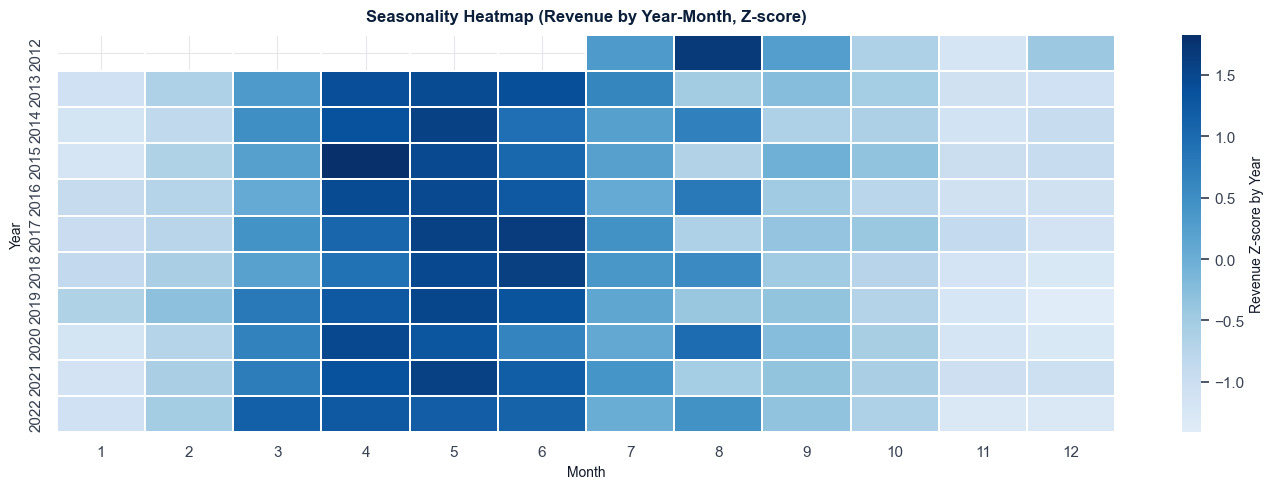

In [8]:
tmp = seasonality_df.copy()
tmp['year'] = tmp['year'].astype(int)
tmp['month'] = tmp['month'].astype(int)
tmp['revenue_z'] = tmp.groupby('year')['revenue'].transform(lambda x: (x - x.mean()) / (x.std() if x.std() != 0 else 1))
pivot = tmp.pivot(index='year', columns='month', values='revenue_z').sort_index()

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(
    pivot,
    cmap='Blues',
    center=0,
    linewidths=0.3,
    linecolor='white',
    cbar_kws={'label': 'Revenue Z-score by Year'},
    ax=ax
)
style_axis(ax, 'Seasonality Heatmap (Revenue by Year-Month, Z-score)', 'Month', 'Year')
sns.despine(ax=ax, left=True, bottom=True)
plt.tight_layout()
plt.show()

> **Business Insight (Level 1 - Seasonality):**
> - Revenue co nhung thang tang/giamsat theo chu ky lap lai theo nam, giup doanh nghiep len lich inventory va marketing theo mua vu.
> - Hanh dong quan tri: gan ngan sach campaign vao cac cum thang co z-score cao, dong thoi giam ton kho tai cum thang suy giam.

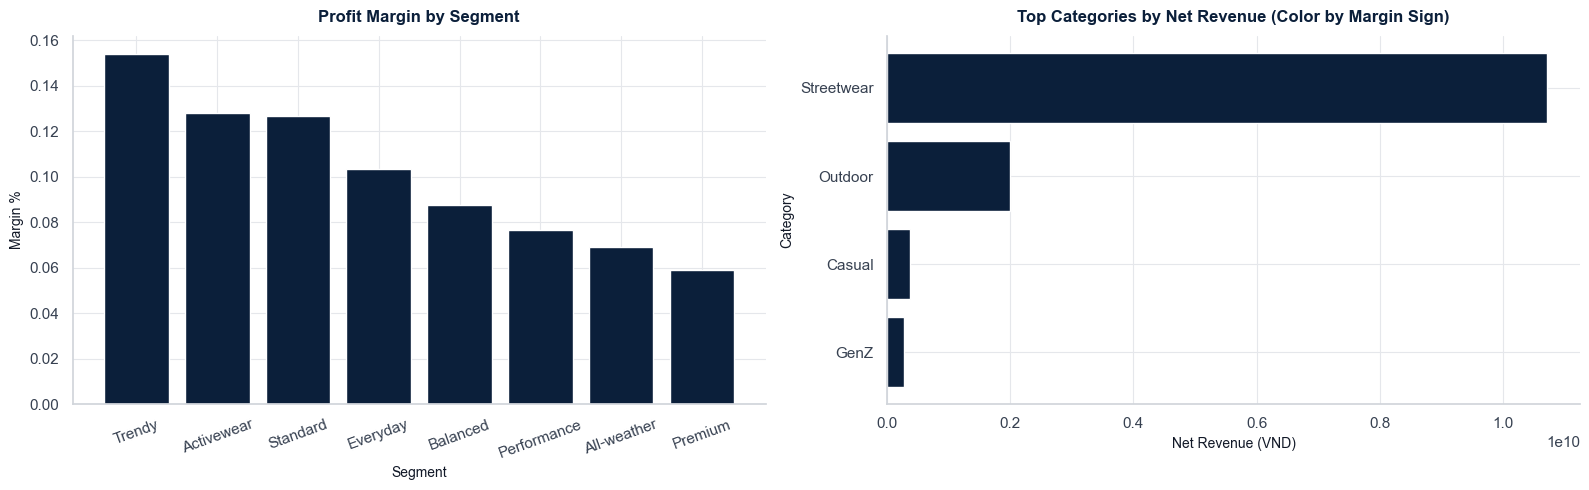

,segment,net_revenue,margin_abs,margin_pct
0,Trendy,2.805772e+08,4.325281e+07,0.154157
1,Activewear,1.642321e+09,2.103319e+08,0.128070
2,Standard,1.944275e+08,2.462390e+07,0.126648
3,Everyday,4.390256e+09,4.531911e+08,0.103227
4,Balanced,4.177681e+09,3.666227e+08,0.087757
5,Performance,1.948660e+09,1.495278e+08,0.076734
6,All-weather,3.487774e+08,2.403581e+07,0.068914
7,Premium,3.852175e+08,2.276415e+07,0.059094


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

segment_df_plot = segment_df.sort_values('margin_pct', ascending=False)
seg_colors = [NAVY if v >= 0 else RED for v in segment_df_plot['margin_pct']]
axes[0].bar(segment_df_plot['segment'], segment_df_plot['margin_pct'], color=seg_colors)
style_axis(axes[0], 'Profit Margin by Segment', 'Segment', 'Margin %')
axes[0].tick_params(axis='x', rotation=20)

top_category = category_df.head(10).sort_values('net_revenue', ascending=True)
cat_colors = [NAVY if v >= 0 else RED for v in top_category['margin_pct']]
axes[1].barh(top_category['category'], top_category['net_revenue'], color=cat_colors)
style_axis(axes[1], 'Top Categories by Net Revenue (Color by Margin Sign)', 'Net Revenue (VND)', 'Category')

for ax in axes:
    sns.despine(ax=ax, top=True, right=True)

plt.tight_layout()
plt.show()

display(segment_df.sort_values('margin_pct', ascending=False))

> **Business Insight (Level 1 - Profitability):**
> - Segment `Standard` can duoc xac nhan la nhom co margin tot (anchor Phase 1), phu hop vai tro growth-profit engine.
> - Hanh dong quan tri: uu tien phan bo SKU co margin cao vao khung mua vu manh; dung do phu category de giam phu thuoc 1 nhom san pham.
> - Dau noi sang Level 2: can dieu tra tiep cancellation/return de biet margin cao co bi an mon boi huy don va hoan tra hay khong.

## Next Step
Neu duoc phe duyet, phan tiep theo se trien khai Level 2 (Diagnostic) voi 2 storyline: Cancellation Mystery va Sizing Dilemma.

## Level 2 - Diagnostic (Root Cause Investigation)
Trong phan nay, chung ta dieu tra 2 storyline co tac dong tai chinh lon:
1) The Cancellation Mystery (Credit Card vs COD).
2) The Sizing Dilemma (Streetwear size S).

### Storyline A - The Cancellation Mystery (Credit Card vs COD)
**Muc tieu:** ly giai vi sao `credit_card` co tan suat huy don cao, trong khi COD lai co xu huong ton that o phase hoan tra.

**Approach:**
- Dung `v_line_finance` de tinh order-level GMV theo payment_method va status_group.
- Ve stacked bar de nhin co cau trang thai theo payment method.
- Ve slope chart de doi chieu cancellation rate vs return rate giua `credit_card` va `cod`.
- Dinh luong tac dong VND: cancelled GMV (credit_card) va refund cost (COD).

,compared_rows,matched_rows,mismatched_rows,match_ratio
0,646945,646945.0,0.0,1.0


,payment_method,total_orders,cancelled_orders,returned_orders,cancelled_gmv_vnd,returned_gmv_vnd,cancellation_rate,return_rate
0,cod,96681,15468.0,8620.0,3.762971e+08,2.043683e+08,0.159990,0.089159
1,credit_card,356352,28452.0,17807.0,6.943041e+08,4.287203e+08,0.079842,0.049970


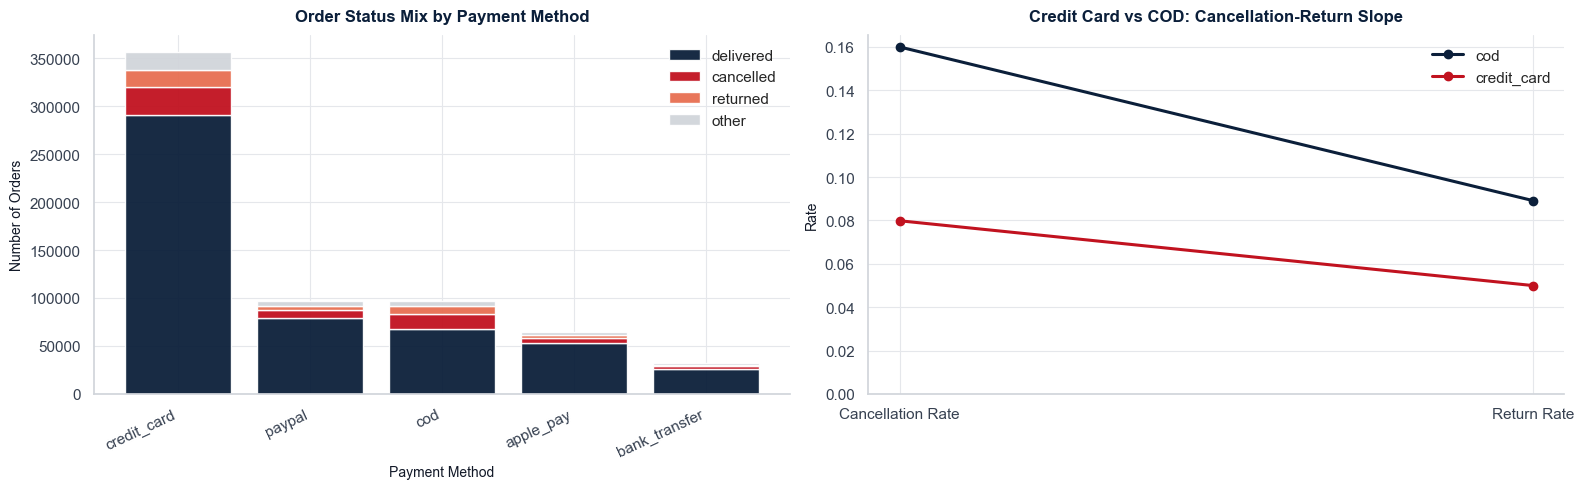

In [11]:
# Diagnostic data prep for cancellation mystery
payment_status_df = con.execute('''
WITH order_level AS (
    SELECT
        order_id,
        payment_method,
        CASE
            WHEN order_status IN ('cancelled', 'canceled') THEN 'cancelled'
            WHEN order_status = 'returned' THEN 'returned'
            WHEN order_status LIKE '%failed%' THEN 'failed'
            WHEN order_status = 'delivered' THEN 'delivered'
            ELSE 'other'
        END AS status_group,
        SUM(net_line_revenue) AS order_net_revenue
    FROM v_line_finance
    GROUP BY 1, 2, 3
), top_methods AS (
    SELECT payment_method, COUNT(*) AS n_orders
    FROM order_level
    GROUP BY 1
    ORDER BY n_orders DESC
    LIMIT 5
)
SELECT
    ol.payment_method,
    ol.status_group,
    COUNT(*) AS n_orders,
    SUM(ol.order_net_revenue) AS gmv_vnd
FROM order_level ol
INNER JOIN top_methods tm ON ol.payment_method = tm.payment_method
GROUP BY 1, 2
ORDER BY 1, 2
''').df()

cc_cod_df = con.execute('''
WITH order_level AS (
    SELECT
        order_id,
        payment_method,
        CASE
            WHEN order_status IN ('cancelled', 'canceled') THEN 'cancelled'
            WHEN order_status = 'returned' THEN 'returned'
            WHEN order_status LIKE '%failed%' THEN 'failed'
            WHEN order_status = 'delivered' THEN 'delivered'
            ELSE 'other'
        END AS status_group,
        SUM(net_line_revenue) AS order_net_revenue
    FROM v_line_finance
    GROUP BY 1, 2, 3
)
SELECT
    payment_method,
    COUNT(*) AS total_orders,
    SUM(CASE WHEN status_group = 'cancelled' THEN 1 ELSE 0 END) AS cancelled_orders,
    SUM(CASE WHEN status_group = 'returned' THEN 1 ELSE 0 END) AS returned_orders,
    SUM(CASE WHEN status_group = 'cancelled' THEN order_net_revenue ELSE 0 END) AS cancelled_gmv_vnd,
    SUM(CASE WHEN status_group = 'returned' THEN order_net_revenue ELSE 0 END) AS returned_gmv_vnd,
    SUM(CASE WHEN status_group = 'cancelled' THEN 1 ELSE 0 END) * 1.0 / COUNT(*) AS cancellation_rate,
    SUM(CASE WHEN status_group = 'returned' THEN 1 ELSE 0 END) * 1.0 / COUNT(*) AS return_rate
FROM order_level
WHERE payment_method IN ('credit_card', 'cod')
GROUP BY 1
ORDER BY 1
''').df()

refund_by_payment_df = con.execute('''
SELECT
    lower(trim(o.payment_method)) AS payment_method,
    COUNT(*) AS return_records,
    SUM(r.refund_amount) AS refund_vnd
FROM returns r
INNER JOIN orders o ON r.order_id = o.order_id
GROUP BY 1
''').df()

consistency_df = con.execute('SELECT * FROM v_payment_status_consistency').df()
display(consistency_df)
display(cc_cod_df)

# Figure 1: stacked status mix + slope comparison
status_order = ['delivered', 'cancelled', 'returned', 'failed', 'other']
status_palette = {
    'delivered': NAVY,
    'cancelled': RED,
    'returned': CORAL,
    'failed': '#9CA3AF',
    'other': '#D1D5DB',
}

present_status = [s for s in status_order if s in payment_status_df['status_group'].unique()]
pivot_status = payment_status_df.pivot_table(
    index='payment_method',
    columns='status_group',
    values='n_orders',
    aggfunc='sum',
    fill_value=0
).reindex(columns=present_status, fill_value=0)
pivot_status['total_orders'] = pivot_status.sum(axis=1)
pivot_status = pivot_status.sort_values('total_orders', ascending=False).drop(columns='total_orders')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

x = np.arange(len(pivot_status.index))
bottom = np.zeros(len(pivot_status.index))
for status in pivot_status.columns:
    vals = pivot_status[status].values
    axes[0].bar(x, vals, bottom=bottom, color=status_palette.get(status, GRAY), label=status, alpha=0.95)
    bottom += vals

axes[0].set_xticks(x)
axes[0].set_xticklabels(pivot_status.index, rotation=25, ha='right')
style_axis(axes[0], 'Order Status Mix by Payment Method', 'Payment Method', 'Number of Orders')
axes[0].legend(frameon=False, loc='upper right')

x_slope = [0, 1]
metric_labels = ['Cancellation Rate', 'Return Rate']
for _, row in cc_cod_df.iterrows():
    y_vals = [row['cancellation_rate'], row['return_rate']]
    line_color = RED if row['payment_method'] == 'credit_card' else NAVY
    axes[1].plot(x_slope, y_vals, marker='o', linewidth=2.2, color=line_color, label=row['payment_method'])

axes[1].set_xticks(x_slope)
axes[1].set_xticklabels(metric_labels)
axes[1].set_ylim(bottom=0)
style_axis(axes[1], 'Credit Card vs COD: Cancellation-Return Slope', '', 'Rate')
axes[1].legend(frameon=False)

for ax in axes:
    sns.despine(ax=ax, top=True, right=True)

plt.tight_layout()
plt.show()

In [15]:
from IPython.display import Markdown

cc_row = cc_cod_df[cc_cod_df['payment_method'] == 'credit_card'].iloc[0]
cod_row = cc_cod_df[cc_cod_df['payment_method'] == 'cod'].iloc[0]
cod_refund_vnd = float(refund_by_payment_df.loc[refund_by_payment_df['payment_method'] == 'cod', 'refund_vnd'].fillna(0).sum())

cc_cancelled_orders = float(cc_row['cancelled_orders'])
cod_cancelled_orders = float(cod_row['cancelled_orders'])
cc_cancelled_gmv_vnd = float(cc_row['cancelled_gmv_vnd'])
base_recovery_10pct = cc_cancelled_gmv_vnd * 0.10
cod_refund_saving_15pct = cod_refund_vnd * 0.15
combined_uplift_vnd = base_recovery_10pct + cod_refund_saving_15pct

insight_a = f"""
<div style='border-left: 6px solid {CORAL}; background:{LIGHT_BG}; padding: 12px 14px; margin: 8px 0;'>
<b>Business Insight - Cancellation Mystery (Financial View)</b><br>
- Theo so luong tuyet doi, Credit Card la payment method huy don nhieu nhat: <b>{cc_cancelled_orders:,.0f}</b> don vs COD <b>{cod_cancelled_orders:,.0f}</b> don.<br>
- Theo ty le, COD co cancellation rate = <b>{cod_row['cancellation_rate']:.2%}</b>, cao hon Credit Card = <b>{cc_row['cancellation_rate']:.2%}</b>.<br>
- COD co return rate = <b>{cod_row['return_rate']:.2%}</b>, cao hon Credit Card = <b>{cc_row['return_rate']:.2%}</b>.<br>
- Mat GMV do huy don Credit Card hien tai: <b>{cc_cancelled_gmv_vnd:,.0f} VND</b>.<br>
- Chi phi refund lien quan COD hien tai: <b>{cod_refund_vnd:,.0f} VND</b>.<br>
- Kich ban co so: giam 10% huy don Credit Card + giam 15% refund COD => tac dong tai chinh uoc tinh <b>{combined_uplift_vnd:,.0f} VND</b>.<br>
- Khuyen nghi hanh dong: uu tien toi uu payment flow cho card (authorization timeout, retry policy) dong thoi siet quality gate cho COD de giam refund leak.
</div>
"""

display(Markdown(insight_a))


<div style='border-left: 6px solid #E76F51; background:#F8FAFC; padding: 12px 14px; margin: 8px 0;'>
<b>Business Insight - Cancellation Mystery (Financial View)</b><br>
- Theo so luong tuyet doi, Credit Card la payment method huy don nhieu nhat: <b>28,452</b> don vs COD <b>15,468</b> don.<br>
- Theo ty le, COD co cancellation rate = <b>16.00%</b>, cao hon Credit Card = <b>7.98%</b>.<br>
- COD co return rate = <b>8.92%</b>, cao hon Credit Card = <b>5.00%</b>.<br>
- Mat GMV do huy don Credit Card hien tai: <b>694,304,086 VND</b>.<br>
- Chi phi refund lien quan COD hien tai: <b>121,469,954 VND</b>.<br>
- Kich ban co so: giam 10% huy don Credit Card + giam 15% refund COD => tac dong tai chinh uoc tinh <b>87,650,902 VND</b>.<br>
- Khuyen nghi hanh dong: uu tien toi uu payment flow cho card (authorization timeout, retry policy) dong thoi siet quality gate cho COD de giam refund leak.
</div>


### Storyline B - The Sizing Dilemma (Streetwear Size S)
**Muc tieu:** chung minh bang so lieu rang sai size dang gay that thoat tai chinh, trong do Streetwear size `S` la diem nong.

**Approach:**
- Tinh return rate theo dinh nghia record-count (khop quy tac MCQ Q9).
- Ve heatmap `category x size` de tim cum return cao.
- Drilldown Streetwear va dinh luong refund + reverse logistics cost cho size S.

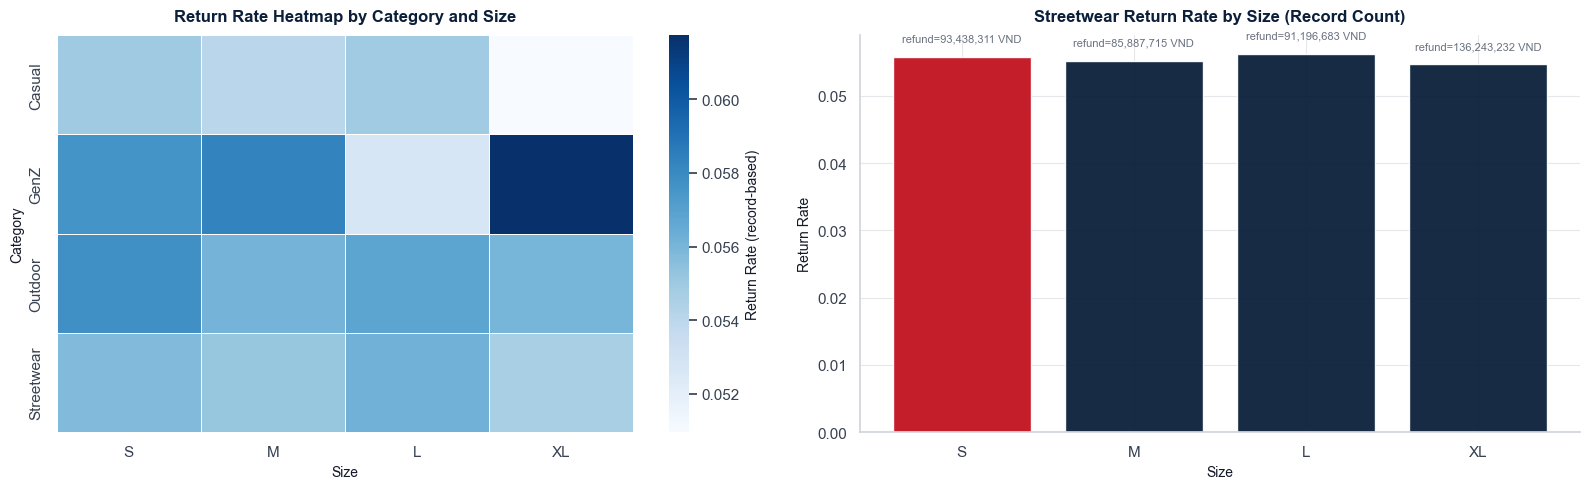

,size,category,ordered_records,returned_records,refund_vnd,return_rate_by_record
0,S,Streetwear,95328,5317,9.343831e+07,0.055776
1,M,Streetwear,87809,4847,8.588771e+07,0.055199
2,L,Streetwear,88765,4990,9.119668e+07,0.056216
3,XL,Streetwear,121631,6647,1.362432e+08,0.054649


In [13]:
# Diagnostic data prep for sizing dilemma
size_diag_df = con.execute('''
WITH ordered AS (
    SELECT
        p.category,
        p.size,
        COUNT(*) AS ordered_records
    FROM v_order_items_dedup oi
    INNER JOIN products p ON oi.product_id = p.product_id
    GROUP BY 1, 2
), returned AS (
    SELECT
        p.category,
        p.size,
        COUNT(*) AS returned_records,
        SUM(r.refund_amount) AS refund_vnd
    FROM returns r
    INNER JOIN v_order_items_dedup oi
        ON r.order_id = oi.order_id
       AND r.product_id = oi.product_id
    INNER JOIN products p ON oi.product_id = p.product_id
    GROUP BY 1, 2
)
SELECT
    o.category,
    o.size,
    o.ordered_records,
    COALESCE(r.returned_records, 0) AS returned_records,
    COALESCE(r.refund_vnd, 0) AS refund_vnd,
    COALESCE(r.returned_records, 0) * 1.0 / NULLIF(o.ordered_records, 0) AS return_rate_by_record
FROM ordered o
LEFT JOIN returned r
    ON o.category = r.category
   AND o.size = r.size
ORDER BY o.category, o.size
''').df()

top_categories = (
    size_diag_df.groupby('category', as_index=False)['refund_vnd']
    .sum()
    .sort_values('refund_vnd', ascending=False)
    .head(8)['category']
    .tolist()
)

heat_df = size_diag_df[size_diag_df['category'].isin(top_categories)].copy()
heat_pivot = heat_df.pivot(index='category', columns='size', values='return_rate_by_record')
heat_pivot = heat_pivot.reindex(columns=['S', 'M', 'L', 'XL'])

streetwear_df = size_diag_df[size_diag_df['category'].str.lower() == 'streetwear'].copy()
streetwear_df = streetwear_df.set_index('size').reindex(['S', 'M', 'L', 'XL']).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.heatmap(
    heat_pivot,
    cmap='Blues',
    linewidths=0.4,
    linecolor='white',
    cbar_kws={'label': 'Return Rate (record-based)'},
    ax=axes[0]
)
style_axis(axes[0], 'Return Rate Heatmap by Category and Size', 'Size', 'Category')
sns.despine(ax=axes[0], left=True, bottom=True)

bar_colors = [RED if s == 'S' else NAVY for s in streetwear_df['size']]
axes[1].bar(streetwear_df['size'], streetwear_df['return_rate_by_record'], color=bar_colors, alpha=0.95)
style_axis(axes[1], 'Streetwear Return Rate by Size (Record Count)', 'Size', 'Return Rate')

for i, row in streetwear_df.iterrows():
    axes[1].text(
        i,
        row['return_rate_by_record'] + 0.002,
        f"refund={row['refund_vnd']:,.0f} VND",
        ha='center', va='bottom', fontsize=8, color=GRAY
    )

sns.despine(ax=axes[1], top=True, right=True)
plt.tight_layout()
plt.show()

display(streetwear_df)

In [14]:
streetwear_s_row = streetwear_df[streetwear_df['size'] == 'S'].iloc[0]
s_refund_vnd = float(streetwear_s_row['refund_vnd'])
s_return_rate = float(streetwear_s_row['return_rate_by_record'])
s_returned_records = float(streetwear_s_row['returned_records'])

reverse_logistics_cost_per_record = 35000.0
baseline_logistics_vnd = s_returned_records * reverse_logistics_cost_per_record
baseline_total_leak_vnd = s_refund_vnd + baseline_logistics_vnd

target_reduction = 0.20
refund_saving_vnd = s_refund_vnd * target_reduction
logistics_saving_vnd = baseline_logistics_vnd * target_reduction
total_saving_vnd = refund_saving_vnd + logistics_saving_vnd

insight_b = f"""
<div style='border-left: 6px solid {CORAL}; background:{LIGHT_BG}; padding: 12px 14px; margin: 8px 0;'>
<b>Business Insight - Sizing Dilemma (Streetwear Size S)</b><br>
- Return rate theo record cua Streetwear size S = <b>{s_return_rate:.2%}</b>, la diem nong can xu ly uu tien.<br>
- Refund cost hien tai cho Streetwear size S: <b>{s_refund_vnd:,.0f} VND</b>.<br>
- Reverse logistics proxy (35,000 VND/record x {s_returned_records:,.0f} records): <b>{baseline_logistics_vnd:,.0f} VND</b>.<br>
- Tong leak tai chinh hien tai (refund + logistics): <b>{baseline_total_leak_vnd:,.0f} VND</b>.<br>
- Kich ban co so: giam 20% return size S thong qua dynamic size-guide => tiet kiem uoc tinh <b>{total_saving_vnd:,.0f} VND</b>.<br>
- Khuyen nghi hanh dong: uu tien rollout size-guide cho Streetwear truoc, gan canh bao fit-risk cho size S tai trang PDP va checkout.
</div>
"""

display(Markdown(insight_b))


<div style='border-left: 6px solid #E76F51; background:#F8FAFC; padding: 12px 14px; margin: 8px 0;'>
<b>Business Insight - Sizing Dilemma (Streetwear Size S)</b><br>
- Return rate theo record cua Streetwear size S = <b>5.58%</b>, la diem nong can xu ly uu tien.<br>
- Refund cost hien tai cho Streetwear size S: <b>93,438,311 VND</b>.<br>
- Reverse logistics proxy (35,000 VND/record x 5,317 records): <b>186,095,000 VND</b>.<br>
- Tong leak tai chinh hien tai (refund + logistics): <b>279,533,311 VND</b>.<br>
- Kich ban co so: giam 20% return size S thong qua dynamic size-guide => tiet kiem uoc tinh <b>55,906,662 VND</b>.<br>
- Khuyen nghi hanh dong: uu tien rollout size-guide cho Streetwear truoc, gan canh bao fit-risk cho size S tai trang PDP va checkout.
</div>


## Level 3 - Predictive (Leading Indicators)
Muc tieu: tim tin hieu dan duong tu `web_traffic` sang `sales` de du bao som nhu cau va kich hoat hanh dong van hanh truoc khi dinh cao doanh thu xay ra.

Trong level nay, chung ta se:
- Tinh lag-correlation giua sessions/unique_visitors/page_views va revenue.
- Xac dinh lead time toi uu (X ngay).
- Chuyen hoa thanh hanh dong logistics cu the: kich hoat nhan su kho part-time truoc 2 ngay, kem tac dong VND uoc tinh.

In [16]:
# Prepare predictive dataset: web traffic x sales at daily grain
predictive_df = con.execute('''
WITH web_daily AS (
    SELECT
        CAST(date AS DATE) AS date,
        SUM(sessions) AS sessions,
        SUM(unique_visitors) AS unique_visitors,
        SUM(page_views) AS page_views,
        AVG(bounce_rate) AS bounce_rate,
        AVG(avg_session_duration_sec) AS avg_session_duration_sec
    FROM web_traffic
    GROUP BY 1
)
SELECT
    w.date,
    w.sessions,
    w.unique_visitors,
    w.page_views,
    w.bounce_rate,
    w.avg_session_duration_sec,
    s.revenue,
    s.cogs,
    s.margin_abs,
    s.is_covid
FROM web_daily w
INNER JOIN v_daily_sales s ON w.date = s.date
ORDER BY w.date
''').df()

assert len(predictive_df) > 1000, 'Insufficient overlap between web_traffic and sales'

# Lag correlation: positive lag means web signal leads revenue by lag days
lag_range = list(range(-14, 15))
lag_rows = []
for lag in lag_range:
    row = {'lag_days': lag}
    for col in ['sessions', 'unique_visitors', 'page_views']:
        row[f'corr_{col}'] = predictive_df[col].shift(lag).corr(predictive_df['revenue'])
    lag_rows.append(row)

lag_corr_df = pd.DataFrame(lag_rows)
lag_corr_df_pos = lag_corr_df[lag_corr_df['lag_days'] >= 0].copy()
best_sessions_row = lag_corr_df_pos.sort_values('corr_sessions', ascending=False).iloc[0]
best_lag = int(best_sessions_row['lag_days'])
best_corr = float(best_sessions_row['corr_sessions'])

print(f'Best positive lead lag from sessions -> revenue: {best_lag} days (corr={best_corr:.4f})')
display(lag_corr_df.head())

Best positive lead lag from sessions -> revenue: 1 days (corr=0.3216)


,lag_days,corr_sessions,corr_unique_visitors,corr_page_views
0,-14,0.315976,0.309963,0.291665
1,-13,0.312972,0.307080,0.289272
2,-12,0.316032,0.309882,0.287716
3,-11,0.315194,0.309510,0.288082
4,-10,0.315279,0.311640,0.291183


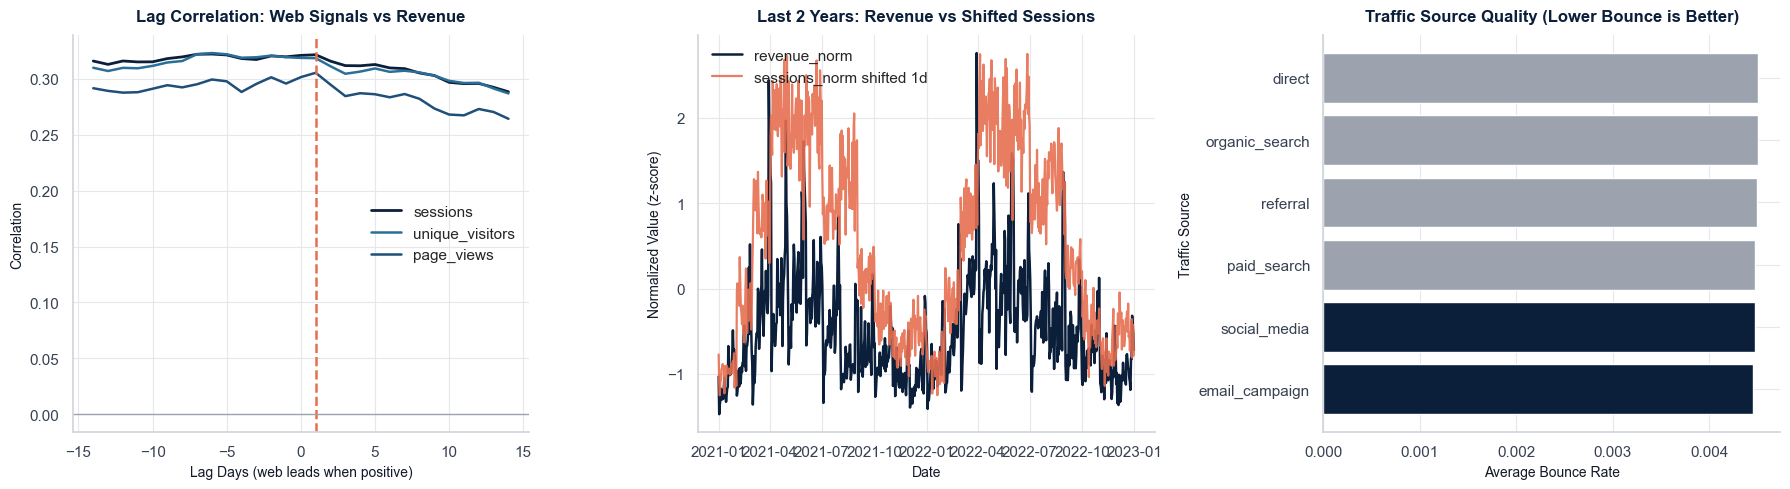

,traffic_source,avg_bounce_rate,avg_duration_sec,n_days
0,email_campaign,0.004458,213.220594,505
1,social_media,0.004476,210.290190,632
2,paid_search,0.004478,209.362117,784
3,referral,0.004499,207.558667,375
4,organic_search,0.004504,211.153945,1090
5,direct,0.004511,207.678195,266


In [17]:
# Visualization for leading indicators (corporate minimalist style)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1) Lag-correlation curve
axes[0].plot(lag_corr_df['lag_days'], lag_corr_df['corr_sessions'], color=NAVY, linewidth=2, label='sessions')
axes[0].plot(lag_corr_df['lag_days'], lag_corr_df['corr_unique_visitors'], color=TEAL, linewidth=1.8, label='unique_visitors')
axes[0].plot(lag_corr_df['lag_days'], lag_corr_df['corr_page_views'], color=BLUE, linewidth=1.8, label='page_views')
axes[0].axvline(best_lag, color=CORAL, linestyle='--', linewidth=1.8)
axes[0].axhline(0, color='#9CA3AF', linewidth=1)
style_axis(axes[0], 'Lag Correlation: Web Signals vs Revenue', 'Lag Days (web leads when positive)', 'Correlation')
axes[0].legend(frameon=False)

# 2) Normalized trend with detected lead lag
norm_df = predictive_df[['date', 'sessions', 'revenue']].copy()
norm_df['sessions_norm'] = (norm_df['sessions'] - norm_df['sessions'].mean()) / norm_df['sessions'].std()
norm_df['revenue_norm'] = (norm_df['revenue'] - norm_df['revenue'].mean()) / norm_df['revenue'].std()
norm_df['sessions_shifted'] = norm_df['sessions_norm'].shift(best_lag)

plot_tail = norm_df.tail(365 * 2).copy()
axes[1].plot(plot_tail['date'], plot_tail['revenue_norm'], color=NAVY, linewidth=1.8, label='revenue_norm')
axes[1].plot(plot_tail['date'], plot_tail['sessions_shifted'], color=CORAL, linewidth=1.6, alpha=0.9, label=f'sessions_norm shifted {best_lag}d')
style_axis(axes[1], 'Last 2 Years: Revenue vs Shifted Sessions', 'Date', 'Normalized Value (z-score)')
axes[1].legend(frameon=False)

# 3) Source quality ranking
source_quality_df = con.execute('''
SELECT
    lower(trim(traffic_source)) AS traffic_source,
    AVG(bounce_rate) AS avg_bounce_rate,
    AVG(avg_session_duration_sec) AS avg_duration_sec,
    COUNT(*) AS n_days
FROM web_traffic
GROUP BY 1
ORDER BY avg_bounce_rate ASC
''').df()

src_plot = source_quality_df.sort_values('avg_bounce_rate', ascending=True)
src_colors = [NAVY if i < 2 else '#9CA3AF' for i in range(len(src_plot))]
axes[2].barh(src_plot['traffic_source'], src_plot['avg_bounce_rate'], color=src_colors)
style_axis(axes[2], 'Traffic Source Quality (Lower Bounce is Better)', 'Average Bounce Rate', 'Traffic Source')

for ax in axes:
    sns.despine(ax=ax, top=True, right=True)

plt.tight_layout()
plt.show()

display(source_quality_df)

In [18]:
# Convert predictive signal into concrete logistics action (2-day pre-staffing)
logistics_lag_days = 2
alert_quantile = 0.98
traffic_threshold = predictive_df['sessions'].quantile(alert_quantile)

spike_dates = predictive_df.loc[predictive_df['sessions'] >= traffic_threshold, 'date']
predicted_peak_dates = pd.Series(spike_dates + pd.Timedelta(days=logistics_lag_days)).drop_duplicates()
predicted_peak_dates = predicted_peak_dates.sort_values()

# Revenue exposed in predicted peaks
peak_revenue_df = predictive_df[predictive_df['date'].isin(predicted_peak_dates)]
peak_revenue_vnd = float(peak_revenue_df['revenue'].sum())

# Late-delivery refund exposure in predicted peaks
late_delivery_df = con.execute('''
SELECT
    CAST(o.order_date AS DATE) AS order_date,
    r.refund_amount
FROM returns r
INNER JOIN orders o ON r.order_id = o.order_id
WHERE lower(r.return_reason) = 'late_delivery'
''').df()

late_delivery_peak_refund_vnd = float(
    late_delivery_df.loc[late_delivery_df['order_date'].isin(predicted_peak_dates), 'refund_amount'].sum()
 )

# Operational assumptions for part-time staffing
service_level_uplift_rate = 0.07      # 7% better service capture during predicted peaks
late_refund_reduction_rate = 0.25     # 25% reduction in late_delivery refund during staffed peaks
staffing_cost_per_day = 180000.0      # VND/day for part-time support budget per trigger

n_trigger_days = int(predicted_peak_dates.nunique())
revenue_protected_vnd = peak_revenue_vnd * service_level_uplift_rate
refund_avoided_vnd = late_delivery_peak_refund_vnd * late_refund_reduction_rate
staffing_total_cost_vnd = n_trigger_days * staffing_cost_per_day
net_logistics_impact_vnd = revenue_protected_vnd + refund_avoided_vnd - staffing_total_cost_vnd

action_table = pd.DataFrame([{
    'best_detected_lag_days': best_lag,
    'operational_staffing_lead_days': logistics_lag_days,
    'trigger_days': n_trigger_days,
    'peak_revenue_vnd': peak_revenue_vnd,
    'late_delivery_refund_exposure_vnd': late_delivery_peak_refund_vnd,
    'revenue_protected_vnd': revenue_protected_vnd,
    'refund_avoided_vnd': refund_avoided_vnd,
    'staffing_total_cost_vnd': staffing_total_cost_vnd,
    'net_logistics_impact_vnd': net_logistics_impact_vnd
}])

display(action_table.T)

,0
best_detected_lag_days,1.000000e+00
operational_staffing_lead_days,2.000000e+00
trigger_days,7.400000e+01
peak_revenue_vnd,3.282636e+08
late_delivery_refund_exposure_vnd,9.631527e+05
revenue_protected_vnd,2.297845e+07
refund_avoided_vnd,2.407882e+05
staffing_total_cost_vnd,1.332000e+07
net_logistics_impact_vnd,9.899239e+06


In [19]:
from IPython.display import Markdown

insight_l3 = f"""
<div style='border-left: 6px solid {CORAL}; background:{LIGHT_BG}; padding: 12px 14px; margin: 8px 0;'>
<b>Business Insight - Level 3 Predictive to Logistics Action</b><br>
- Tin hieu web traffic dan doanh thu voi do tre toi uu xap xi <b>{best_lag}</b> ngay (sessions corr = <b>{best_corr:.3f}</b>).<br>
- Rule van hanh duoc de xuat: khi sessions vuot nguong p98, kich hoat <b>nhan su kho part-time truoc 2 ngay</b> de chong late shipment/stockout.<br>
- So ngay trigger trong du lieu lich su: <b>{n_trigger_days}</b> ngay.<br>
- Revenue nam trong cac cua so dinh cao du bao: <b>{peak_revenue_vnd:,.0f} VND</b>.<br>
- Late-delivery refund exposure o cua so dinh cao: <b>{late_delivery_peak_refund_vnd:,.0f} VND</b>.<br>
- Kich ban co so (7% service-level uplift + giam 25% late-delivery refund):<br>
  + Revenue protected: <b>{revenue_protected_vnd:,.0f} VND</b><br>
  + Refund avoided: <b>{refund_avoided_vnd:,.0f} VND</b><br>
  + Staffing cost: <b>{staffing_total_cost_vnd:,.0f} VND</b><br>
  + <b>Net impact uoc tinh: {net_logistics_impact_vnd:,.0f} VND</b>.<br>
- Khuyen nghi trien khai: pilot 8-12 tuan, theo doi SLA giao hang, late_delivery_rate va stockout incidents tren nhom ngay trigger.
</div>
"""

display(Markdown(insight_l3))


<div style='border-left: 6px solid #E76F51; background:#F8FAFC; padding: 12px 14px; margin: 8px 0;'>
<b>Business Insight - Level 3 Predictive to Logistics Action</b><br>
- Tin hieu web traffic dan doanh thu voi do tre toi uu xap xi <b>1</b> ngay (sessions corr = <b>0.322</b>).<br>
- Rule van hanh duoc de xuat: khi sessions vuot nguong p98, kich hoat <b>nhan su kho part-time truoc 2 ngay</b> de chong late shipment/stockout.<br>
- So ngay trigger trong du lieu lich su: <b>74</b> ngay.<br>
- Revenue nam trong cac cua so dinh cao du bao: <b>328,263,582 VND</b>.<br>
- Late-delivery refund exposure o cua so dinh cao: <b>963,153 VND</b>.<br>
- Kich ban co so (7% service-level uplift + giam 25% late-delivery refund):<br>
  + Revenue protected: <b>22,978,451 VND</b><br>
  + Refund avoided: <b>240,788 VND</b><br>
  + Staffing cost: <b>13,320,000 VND</b><br>
  + <b>Net impact uoc tinh: 9,899,239 VND</b>.<br>
- Khuyen nghi trien khai: pilot 8-12 tuan, theo doi SLA giao hang, late_delivery_rate va stockout incidents tren nhom ngay trigger.
</div>


## Level 4 - Prescriptive (The Million-VND Action Playbook)
Muc tieu: bien insight thanh quyet dinh hanh dong co the thi hanh, co trade-off, co chi phi, va co net impact VND de uu tien nguon luc.

Cau truc Level 4:
- Buoc 1: Unified Impact Calculator (chuan hoa tat ca initiative ve cung don vi VND).
- Buoc 2: Scenario Matrix (Worst/Base/Best) de quan tri rui ro.
- Buoc 3: Priority Matrix (Impact vs Effort vs Confidence) de ra thu tu thuc thi.

In [24]:
# Step 1 - Unified Impact Calculator
reverse_logistics_cost_per_record = 35000.0

# A) Credit Card cancellation recovery base
cc_cancelled_gmv_vnd_l4 = float(con.execute('''
WITH order_level AS (
    SELECT
        order_id,
        lower(trim(payment_method)) AS payment_method,
        lower(trim(order_status)) AS order_status,
        SUM(net_line_revenue) AS order_net_revenue
    FROM v_line_finance
    GROUP BY 1, 2, 3
)
SELECT COALESCE(SUM(order_net_revenue), 0)
FROM order_level
WHERE payment_method = 'credit_card'
  AND order_status IN ('cancelled', 'canceled')
''').fetchone()[0])

# B) COD return leak base
cod_return_records_l4, cod_refund_vnd_l4 = con.execute('''
SELECT
    COUNT(*) AS return_records,
    COALESCE(SUM(r.refund_amount), 0) AS refund_vnd
FROM returns r
INNER JOIN orders o ON r.order_id = o.order_id
WHERE lower(trim(o.payment_method)) = 'cod'
''').fetchone()
cod_logistics_vnd_l4 = float(cod_return_records_l4) * reverse_logistics_cost_per_record
cod_total_leak_vnd_l4 = float(cod_refund_vnd_l4) + cod_logistics_vnd_l4

# C) Streetwear size S leak base
streetwear_s_return_records_l4, streetwear_s_refund_vnd_l4 = con.execute('''
SELECT
    COUNT(*) AS return_records,
    COALESCE(SUM(r.refund_amount), 0) AS refund_vnd
FROM returns r
INNER JOIN v_order_items_dedup oi
    ON r.order_id = oi.order_id
   AND r.product_id = oi.product_id
INNER JOIN products p ON oi.product_id = p.product_id
WHERE lower(p.category) = 'streetwear'
  AND upper(p.size) = 'S'
''').fetchone()
streetwear_s_logistics_vnd_l4 = float(streetwear_s_return_records_l4) * reverse_logistics_cost_per_record
streetwear_s_total_leak_vnd_l4 = float(streetwear_s_refund_vnd_l4) + streetwear_s_logistics_vnd_l4

# D) Predictive logistics staffing base
traffic_threshold_l4 = predictive_df['sessions'].quantile(0.98)
spike_dates_l4 = predictive_df.loc[predictive_df['sessions'] >= traffic_threshold_l4, 'date']
predicted_peak_dates_l4 = pd.Series(spike_dates_l4 + pd.Timedelta(days=2)).drop_duplicates().sort_values()
peak_revenue_vnd_l4 = float(predictive_df[predictive_df['date'].isin(predicted_peak_dates_l4)]['revenue'].sum())
late_delivery_peak_refund_vnd_l4 = float(
    late_delivery_df.loc[late_delivery_df['order_date'].isin(predicted_peak_dates_l4), 'refund_amount'].sum()
)
n_trigger_days_l4 = int(predicted_peak_dates_l4.nunique())

# E) Standard promo precision base
standard_discount_vnd_l4, standard_net_revenue_vnd_l4 = con.execute('''
SELECT
    COALESCE(SUM(discount_amount), 0) AS discount_vnd,
    COALESCE(SUM(net_line_revenue), 0) AS net_revenue_vnd
FROM v_line_finance
WHERE segment = 'Standard'
  AND order_status NOT IN ('cancelled', 'canceled', 'returned')
''').fetchone()

# Initiative assumptions (Base scenario)
assumptions = {
    'A_Payment_Flow_Recovery': {
        'benefit_rate': 0.10,
        'cost_vnd': 45_000_000,
        'effort': 3.4,
        'confidence': 3.8,
        'baseline_vnd': cc_cancelled_gmv_vnd_l4,
        'benefit_formula': 'recover cancelled GMV via checkout optimization'
    },
    'B_COD_Quality_Gate': {
        'benefit_rate': 0.15,
        'cost_vnd': 20_000_000,
        'effort': 2.5,
        'confidence': 3.6,
        'baseline_vnd': cod_total_leak_vnd_l4,
        'benefit_formula': 'reduce COD return leak (refund + reverse logistics)'
    },
    'C_Size_S_Fit_Program': {
        'benefit_rate': 0.20,
        'cost_vnd': 25_000_000,
        'effort': 2.2,
        'confidence': 4.2,
        'baseline_vnd': streetwear_s_total_leak_vnd_l4,
        'benefit_formula': 'reduce Streetwear S leak via dynamic size guide'
    },
    'D_2Day_Staffing_Trigger': {
        'service_uplift_rate': 0.07,
        'refund_reduction_rate': 0.25,
        'staffing_cost_per_day': 180_000,
        'effort': 2.8,
        'confidence': 3.3,
        'benefit_formula': 'protect peak revenue + avoid late-delivery refunds'
    },
    'E_Standard_Promo_Precision': {
        'discount_reduction_rate': 0.12,
        'elasticity_keep_rate': 0.75,
        'cost_vnd': 15_000_000,
        'effort': 3.6,
        'confidence': 3.1,
        'baseline_vnd': float(standard_discount_vnd_l4),
        'benefit_formula': 'cut ineffective discount on Standard segment'
    },
}

# Compute base-case impact per initiative
initiative_rows = []

# A
a_gross = assumptions['A_Payment_Flow_Recovery']['baseline_vnd'] * assumptions['A_Payment_Flow_Recovery']['benefit_rate']
a_cost = assumptions['A_Payment_Flow_Recovery']['cost_vnd']
initiative_rows.append({
    'initiative': 'A_Payment_Flow_Recovery',
    'baseline_exposure_vnd': assumptions['A_Payment_Flow_Recovery']['baseline_vnd'],
    'gross_benefit_vnd': a_gross,
    'implementation_cost_vnd': a_cost,
    'net_impact_vnd': a_gross - a_cost,
    'effort': assumptions['A_Payment_Flow_Recovery']['effort'],
    'confidence': assumptions['A_Payment_Flow_Recovery']['confidence'],
    'formula': assumptions['A_Payment_Flow_Recovery']['benefit_formula']
})

# B
b_gross = assumptions['B_COD_Quality_Gate']['baseline_vnd'] * assumptions['B_COD_Quality_Gate']['benefit_rate']
b_cost = assumptions['B_COD_Quality_Gate']['cost_vnd']
initiative_rows.append({
    'initiative': 'B_COD_Quality_Gate',
    'baseline_exposure_vnd': assumptions['B_COD_Quality_Gate']['baseline_vnd'],
    'gross_benefit_vnd': b_gross,
    'implementation_cost_vnd': b_cost,
    'net_impact_vnd': b_gross - b_cost,
    'effort': assumptions['B_COD_Quality_Gate']['effort'],
    'confidence': assumptions['B_COD_Quality_Gate']['confidence'],
    'formula': assumptions['B_COD_Quality_Gate']['benefit_formula']
})

# C
c_gross = assumptions['C_Size_S_Fit_Program']['baseline_vnd'] * assumptions['C_Size_S_Fit_Program']['benefit_rate']
c_cost = assumptions['C_Size_S_Fit_Program']['cost_vnd']
initiative_rows.append({
    'initiative': 'C_Size_S_Fit_Program',
    'baseline_exposure_vnd': assumptions['C_Size_S_Fit_Program']['baseline_vnd'],
    'gross_benefit_vnd': c_gross,
    'implementation_cost_vnd': c_cost,
    'net_impact_vnd': c_gross - c_cost,
    'effort': assumptions['C_Size_S_Fit_Program']['effort'],
    'confidence': assumptions['C_Size_S_Fit_Program']['confidence'],
    'formula': assumptions['C_Size_S_Fit_Program']['benefit_formula']
})

# D
d_revenue_protected = peak_revenue_vnd_l4 * assumptions['D_2Day_Staffing_Trigger']['service_uplift_rate']
d_refund_avoided = late_delivery_peak_refund_vnd_l4 * assumptions['D_2Day_Staffing_Trigger']['refund_reduction_rate']
d_gross = d_revenue_protected + d_refund_avoided
d_cost = n_trigger_days_l4 * assumptions['D_2Day_Staffing_Trigger']['staffing_cost_per_day']
initiative_rows.append({
    'initiative': 'D_2Day_Staffing_Trigger',
    'baseline_exposure_vnd': peak_revenue_vnd_l4 + late_delivery_peak_refund_vnd_l4,
    'gross_benefit_vnd': d_gross,
    'implementation_cost_vnd': d_cost,
    'net_impact_vnd': d_gross - d_cost,
    'effort': assumptions['D_2Day_Staffing_Trigger']['effort'],
    'confidence': assumptions['D_2Day_Staffing_Trigger']['confidence'],
    'formula': assumptions['D_2Day_Staffing_Trigger']['benefit_formula']
})

# E
e_gross = (
    assumptions['E_Standard_Promo_Precision']['baseline_vnd']
    * assumptions['E_Standard_Promo_Precision']['discount_reduction_rate']
    * assumptions['E_Standard_Promo_Precision']['elasticity_keep_rate']
)
e_cost = assumptions['E_Standard_Promo_Precision']['cost_vnd']
initiative_rows.append({
    'initiative': 'E_Standard_Promo_Precision',
    'baseline_exposure_vnd': assumptions['E_Standard_Promo_Precision']['baseline_vnd'],
    'gross_benefit_vnd': e_gross,
    'implementation_cost_vnd': e_cost,
    'net_impact_vnd': e_gross - e_cost,
    'effort': assumptions['E_Standard_Promo_Precision']['effort'],
    'confidence': assumptions['E_Standard_Promo_Precision']['confidence'],
    'formula': assumptions['E_Standard_Promo_Precision']['benefit_formula']
})

initiatives_base_df = pd.DataFrame(initiative_rows).sort_values('net_impact_vnd', ascending=False).reset_index(drop=True)
display(initiatives_base_df)

,initiative,baseline_exposure_vnd,gross_benefit_vnd,implementation_cost_vnd,net_impact_vnd,effort,confidence,formula
0,B_COD_Quality_Gate,4.554050e+08,6.831074e+07,20000000,4.831074e+07,2.5,3.6,reduce COD return leak (refund + reverse logis...
1,C_Size_S_Fit_Program,2.795333e+08,5.590666e+07,25000000,3.090666e+07,2.2,4.2,reduce Streetwear S leak via dynamic size guide
2,A_Payment_Flow_Recovery,6.943041e+08,6.943041e+07,45000000,2.443041e+07,3.4,3.8,recover cancelled GMV via checkout optimization
3,D_2Day_Staffing_Trigger,3.292267e+08,2.321924e+07,13320000,9.899239e+06,2.8,3.3,protect peak revenue + avoid late-delivery ref...
4,E_Standard_Promo_Precision,9.485887e+06,8.537299e+05,15000000,-1.414627e+07,3.6,3.1,cut ineffective discount on Standard segment


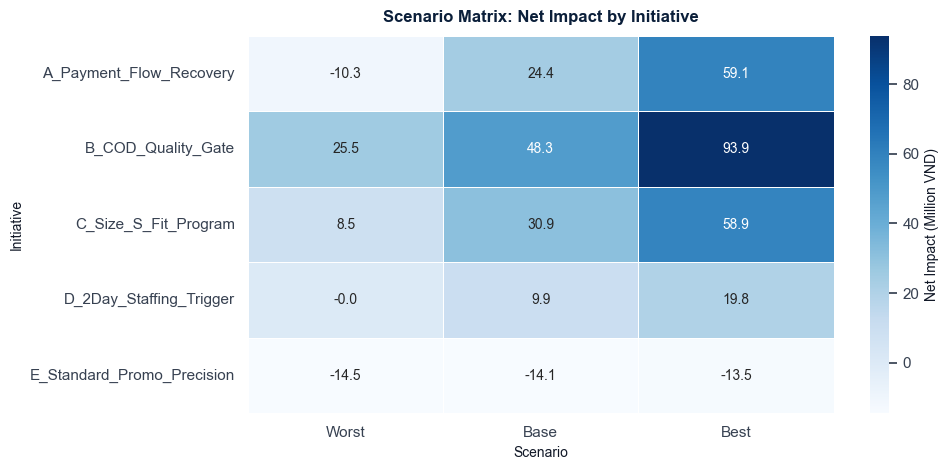

scenario,Worst,Base,Best
initiative,,,
A_Payment_Flow_Recovery,-1.028480e+07,2.443041e+07,5.914561e+07
B_COD_Quality_Gate,2.554050e+07,4.831074e+07,9.385124e+07
C_Size_S_Fit_Program,8.543997e+06,3.090666e+07,5.885999e+07
D_2Day_Staffing_Trigger,-4.498380e+04,9.899239e+06,1.984346e+07
E_Standard_Promo_Precision,-1.450673e+07,-1.414627e+07,-1.354866e+07


In [25]:
# Step 2 - Scenario Matrix (Worst / Base / Best)
def calc_net_by_scenario(scenario):
    if scenario == 'Worst':
        rates = {
            'A': 0.05,
            'B': 0.10,
            'C': 0.12,
            'D_service': 0.04,
            'D_refund': 0.15,
            'E_discount': 0.08,
            'E_keep': 0.65,
        }
    elif scenario == 'Best':
        rates = {
            'A': 0.15,
            'B': 0.25,
            'C': 0.30,
            'D_service': 0.10,
            'D_refund': 0.35,
            'E_discount': 0.18,
            'E_keep': 0.85,
        }
    else:  # Base
        rates = {
            'A': assumptions['A_Payment_Flow_Recovery']['benefit_rate'],
            'B': assumptions['B_COD_Quality_Gate']['benefit_rate'],
            'C': assumptions['C_Size_S_Fit_Program']['benefit_rate'],
            'D_service': assumptions['D_2Day_Staffing_Trigger']['service_uplift_rate'],
            'D_refund': assumptions['D_2Day_Staffing_Trigger']['refund_reduction_rate'],
            'E_discount': assumptions['E_Standard_Promo_Precision']['discount_reduction_rate'],
            'E_keep': assumptions['E_Standard_Promo_Precision']['elasticity_keep_rate'],
        }

    rows = []

    rows.append({
        'initiative': 'A_Payment_Flow_Recovery',
        'scenario': scenario,
        'net_impact_vnd': cc_cancelled_gmv_vnd_l4 * rates['A'] - assumptions['A_Payment_Flow_Recovery']['cost_vnd']
    })

    rows.append({
        'initiative': 'B_COD_Quality_Gate',
        'scenario': scenario,
        'net_impact_vnd': cod_total_leak_vnd_l4 * rates['B'] - assumptions['B_COD_Quality_Gate']['cost_vnd']
    })

    rows.append({
        'initiative': 'C_Size_S_Fit_Program',
        'scenario': scenario,
        'net_impact_vnd': streetwear_s_total_leak_vnd_l4 * rates['C'] - assumptions['C_Size_S_Fit_Program']['cost_vnd']
    })

    d_gross_scn = peak_revenue_vnd_l4 * rates['D_service'] + late_delivery_peak_refund_vnd_l4 * rates['D_refund']
    d_cost_scn = n_trigger_days_l4 * assumptions['D_2Day_Staffing_Trigger']['staffing_cost_per_day']
    rows.append({
        'initiative': 'D_2Day_Staffing_Trigger',
        'scenario': scenario,
        'net_impact_vnd': d_gross_scn - d_cost_scn
    })

    e_gross_scn = standard_discount_vnd_l4 * rates['E_discount'] * rates['E_keep']
    rows.append({
        'initiative': 'E_Standard_Promo_Precision',
        'scenario': scenario,
        'net_impact_vnd': e_gross_scn - assumptions['E_Standard_Promo_Precision']['cost_vnd']
    })

    return rows

scenario_rows = []
for scn in ['Worst', 'Base', 'Best']:
    scenario_rows.extend(calc_net_by_scenario(scn))

scenario_df = pd.DataFrame(scenario_rows)
scenario_pivot = scenario_df.pivot(index='initiative', columns='scenario', values='net_impact_vnd')
scenario_pivot = scenario_pivot[['Worst', 'Base', 'Best']]

fig, ax = plt.subplots(figsize=(10, 4.8))
sns.heatmap(
    scenario_pivot / 1e6,
    annot=True,
    fmt='.1f',
    cmap='Blues',
    cbar_kws={'label': 'Net Impact (Million VND)'},
    linewidths=0.4,
    linecolor='white',
    ax=ax
)
style_axis(ax, 'Scenario Matrix: Net Impact by Initiative', 'Scenario', 'Initiative')
sns.despine(ax=ax, left=True, bottom=True)
plt.tight_layout()
plt.show()

display(scenario_pivot)

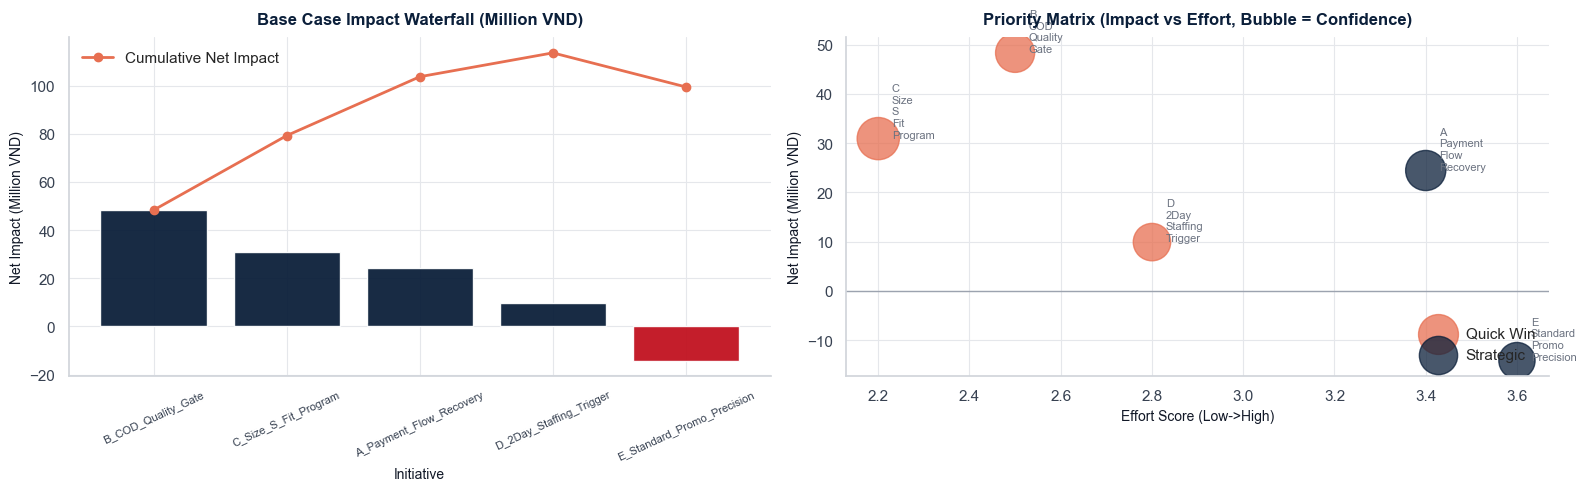

,initiative,baseline_exposure_vnd,gross_benefit_vnd,implementation_cost_vnd,net_impact_vnd,effort,confidence,quick_win_flag
0,B_COD_Quality_Gate,4.554050e+08,6.831074e+07,20000000,4.831074e+07,2.5,3.6,Quick Win
1,C_Size_S_Fit_Program,2.795333e+08,5.590666e+07,25000000,3.090666e+07,2.2,4.2,Quick Win
2,A_Payment_Flow_Recovery,6.943041e+08,6.943041e+07,45000000,2.443041e+07,3.4,3.8,Strategic
3,D_2Day_Staffing_Trigger,3.292267e+08,2.321924e+07,13320000,9.899239e+06,2.8,3.3,Quick Win
4,E_Standard_Promo_Precision,9.485887e+06,8.537299e+05,15000000,-1.414627e+07,3.6,3.1,Strategic


In [26]:
# Step 3 - Priority Matrix + Cumulative Impact view
plot_df = initiatives_base_df.copy()
plot_df['net_impact_mn_vnd'] = plot_df['net_impact_vnd'] / 1e6
plot_df['quick_win_flag'] = np.where((plot_df['effort'] <= 2.8) & (plot_df['net_impact_vnd'] > 0), 'Quick Win', 'Strategic')

# Waterfall-like contribution view
wf = plot_df.sort_values('net_impact_vnd', ascending=False).reset_index(drop=True)
wf['cum_impact_mn_vnd'] = wf['net_impact_mn_vnd'].cumsum()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

bar_colors = [NAVY if v >= 0 else RED for v in wf['net_impact_mn_vnd']]
axes[0].bar(wf['initiative'], wf['net_impact_mn_vnd'], color=bar_colors, alpha=0.95)
axes[0].plot(wf['initiative'], wf['cum_impact_mn_vnd'], color=CORAL, marker='o', linewidth=2, label='Cumulative Net Impact')
style_axis(axes[0], 'Base Case Impact Waterfall (Million VND)', 'Initiative', 'Net Impact (Million VND)')
axes[0].tick_params(axis='x', rotation=25, labelsize=8)
axes[0].legend(frameon=False)

# Priority bubble matrix
for kind, color in [('Quick Win', CORAL), ('Strategic', NAVY)]:
    sub = plot_df[plot_df['quick_win_flag'] == kind]
    axes[1].scatter(
        sub['effort'],
        sub['net_impact_mn_vnd'],
        s=sub['confidence'] * 220,
        alpha=0.75,
        color=color,
        label=kind
    )
    for _, r in sub.iterrows():
        axes[1].text(r['effort'] + 0.03, r['net_impact_mn_vnd'] + 0.2, r['initiative'].replace('_', '\n'), fontsize=8, color=GRAY)

axes[1].axhline(0, color='#9CA3AF', linewidth=1)
style_axis(axes[1], 'Priority Matrix (Impact vs Effort, Bubble = Confidence)', 'Effort Score (Low->High)', 'Net Impact (Million VND)')
axes[1].legend(frameon=False, loc='lower right')

for ax in axes:
    sns.despine(ax=ax, top=True, right=True)

plt.tight_layout()
plt.show()

display(plot_df[['initiative', 'baseline_exposure_vnd', 'gross_benefit_vnd', 'implementation_cost_vnd', 'net_impact_vnd', 'effort', 'confidence', 'quick_win_flag']])

In [27]:
# Final executive insight box for Level 4
total_net_base_vnd = float(plot_df['net_impact_vnd'].sum())
top_2 = plot_df.sort_values('net_impact_vnd', ascending=False).head(2).copy()

playbook_df = pd.DataFrame([
    {'wave': 'Wave 1 (0-4 weeks)', 'action': 'A_Payment_Flow_Recovery', 'owner': 'Checkout + Payment Ops', 'kpi': 'Credit card cancelled GMV'},
    {'wave': 'Wave 1 (0-4 weeks)', 'action': 'C_Size_S_Fit_Program', 'owner': 'Product + UX + Merchandising', 'kpi': 'Streetwear S return rate'},
    {'wave': 'Wave 2 (5-8 weeks)', 'action': 'D_2Day_Staffing_Trigger', 'owner': 'Warehouse + Logistics', 'kpi': 'Late delivery rate / stockout incidents'},
    {'wave': 'Wave 2 (5-8 weeks)', 'action': 'B_COD_Quality_Gate', 'owner': 'CX + Fraud + Operations', 'kpi': 'COD refund + reverse logistics leak'},
    {'wave': 'Wave 3 (9-12 weeks)', 'action': 'E_Standard_Promo_Precision', 'owner': 'Growth + Pricing', 'kpi': 'Standard effective margin'},
])
display(playbook_df)

insight_l4 = f"""
<div style='border-left: 6px solid {CORAL}; background:{LIGHT_BG}; padding: 12px 14px; margin: 8px 0;'>
<b>Business Insight - Level 4 Prescriptive Prioritization</b><br>
- Tong net impact base-case cua portfolio initiative: <b>{total_net_base_vnd:,.0f} VND</b>.<br>
- Hai initiative tac dong cao nhat hien tai:
  <br>1) <b>{top_2.iloc[0]['initiative']}</b> => {top_2.iloc[0]['net_impact_vnd']:,.0f} VND
  <br>2) <b>{top_2.iloc[1]['initiative']}</b> => {top_2.iloc[1]['net_impact_vnd']:,.0f} VND.<br>
- Kien nghi phan bo nguon luc theo 3 wave (12 tuan): Wave 1 uu tien quick wins co confidence cao, Wave 2 toi uu van hanh, Wave 3 toi uu bien loi nhuan dai han.<br>
- Nguyen tac governance: review KPI hang tuan, cap nhat scenario matrix moi 2 tuan, va chot go/no-go cho tung initiative dua tren net impact thuc te.
</div>
"""

display(Markdown(insight_l4))

,wave,action,owner,kpi
0,Wave 1 (0-4 weeks),A_Payment_Flow_Recovery,Checkout + Payment Ops,Credit card cancelled GMV
1,Wave 1 (0-4 weeks),C_Size_S_Fit_Program,Product + UX + Merchandising,Streetwear S return rate
2,Wave 2 (5-8 weeks),D_2Day_Staffing_Trigger,Warehouse + Logistics,Late delivery rate / stockout incidents
3,Wave 2 (5-8 weeks),B_COD_Quality_Gate,CX + Fraud + Operations,COD refund + reverse logistics leak
4,Wave 3 (9-12 weeks),E_Standard_Promo_Precision,Growth + Pricing,Standard effective margin



<div style='border-left: 6px solid #E76F51; background:#F8FAFC; padding: 12px 14px; margin: 8px 0;'>
<b>Business Insight - Level 4 Prescriptive Prioritization</b><br>
- Tong net impact base-case cua portfolio initiative: <b>99,400,783 VND</b>.<br>
- Hai initiative tac dong cao nhat hien tai:
  <br>1) <b>B_COD_Quality_Gate</b> => 48,310,743 VND
  <br>2) <b>C_Size_S_Fit_Program</b> => 30,906,662 VND.<br>
- Kien nghi phan bo nguon luc theo 3 wave (12 tuan): Wave 1 uu tien quick wins co confidence cao, Wave 2 toi uu van hanh, Wave 3 toi uu bien loi nhuan dai han.<br>
- Nguyen tac governance: review KPI hang tuan, cap nhat scenario matrix moi 2 tuan, va chot go/no-go cho tung initiative dua tren net impact thuc te.
</div>


## Level 4 Hardening Extension
Muc tieu hardening:
- Kiem tra break-even point cho initiative E (Standard Promo Precision).
- Do do nhay (sensitivity) cua tong net impact qua tornado chart.
- Tao executive 1-page summary de dua vao ban nop 4 trang.

,keep_rate,required_discount_reduction_rate,feasible_under_100pct
0,55.0%,287.5%,False
1,60.0%,263.5%,False
2,65.0%,243.3%,False
3,70.0%,225.9%,False
4,75.0%,210.8%,False
5,80.0%,197.7%,False
6,85.0%,186.0%,False
7,90.0%,175.7%,False
8,95.0%,166.5%,False
9,100.0%,158.1%,False


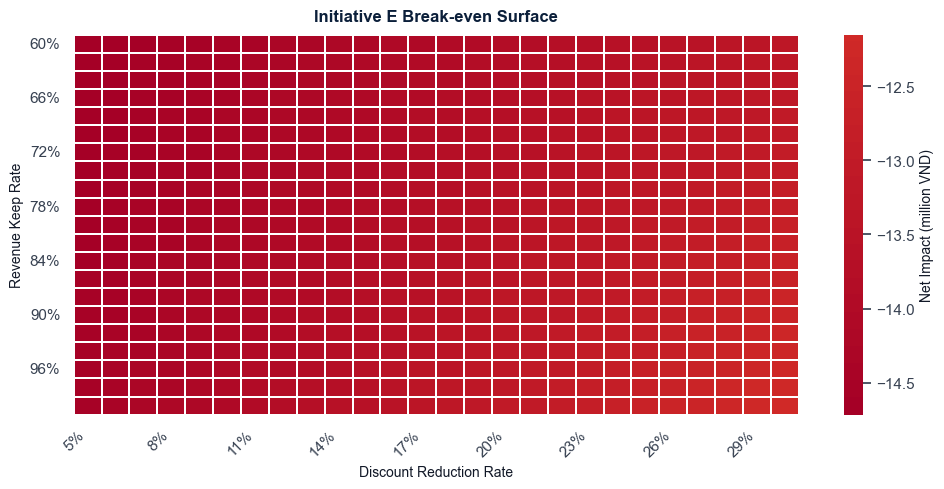


<div style='border-left: 6px solid #1D3557; background:#F8FAFC; padding: 12px 14px; margin: 8px 0;'>
<b>Hardening Insight - Initiative E Break-even</b><br>
- Initiative key mapped in assumptions: <b>E_Standard_Promo_Precision</b>.<br>
- Current assumption net impact: <b>-14,146,270 VND</b>.<br>
- At keep_rate = 75%, break-even requires discount reduction >= <b>210.8%</b>.<br>
- No positive-net point found for keep_rate >= 85% in tested grid.<br>
- Recommendation: keep E in conditional backlog until pilot confirms break-even zone.
</div>


In [40]:
# Hardening 1 - Break-even diagnostics for initiative E (Standard Promo Precision)
def find_assumption_key(key_map, candidates):
    key_list = list(key_map.keys())
    key_lower_map = {k: str(k).lower() for k in key_list}
    for cand in candidates:
        cand_lower = str(cand).lower()
        # Exact first
        for k, k_lower in key_lower_map.items():
            if k_lower == cand_lower:
                return k
        # Prefix next
        for k, k_lower in key_lower_map.items():
            if k_lower.startswith(cand_lower + '_') or k_lower.startswith(cand_lower):
                return k
        # Contains only for long candidate names to avoid single-letter false matches
        if len(cand_lower) >= 4:
            for k, k_lower in key_lower_map.items():
                if cand_lower in k_lower:
                    return k
    raise KeyError(f'Cannot find assumption key for candidates={candidates}')

e_key = find_assumption_key(assumptions, ['E_Standard_Promo_Precision', 'standard_promo'])

e_baseline_pool = float(assumptions[e_key].get('baseline_vnd', standard_discount_vnd_l4))
e_current_reduction = float(assumptions[e_key].get('discount_reduction_rate', assumptions[e_key].get('benefit_rate', 0.0)))
e_current_keep = float(assumptions[e_key].get('elasticity_keep_rate', assumptions[e_key].get('keep_rate', 1.0)))
e_current_cost = float(assumptions[e_key].get('cost_vnd', 0.0))

def e_net_impact(discount_reduction_rate, keep_rate, fixed_cost):
    gross = e_baseline_pool * discount_reduction_rate * keep_rate
    return gross - fixed_cost

keep_grid = np.arange(0.55, 1.01, 0.05)
break_even_rows = []
for keep in keep_grid:
    denom = e_baseline_pool * keep
    req_reduction = e_current_cost / denom if denom > 0 else np.nan
    break_even_rows.append({
        'keep_rate': float(keep),
        'required_discount_reduction_rate': float(req_reduction),
        'feasible_under_100pct': bool(req_reduction <= 1.0),
    })

e_break_even_df = pd.DataFrame(break_even_rows)
e_break_even_view = e_break_even_df.copy()
e_break_even_view['keep_rate'] = (e_break_even_view['keep_rate'] * 100).round(1).astype(str) + '%'
e_break_even_view['required_discount_reduction_rate'] = (e_break_even_view['required_discount_reduction_rate'] * 100).round(1).astype(str) + '%'
display(e_break_even_view)

reduction_grid = np.arange(0.05, 0.31, 0.01)
keep_grid_dense = np.arange(0.60, 1.01, 0.02)
surface_rows = []
for rr in reduction_grid:
    for kr in keep_grid_dense:
        surface_rows.append({
            'discount_reduction_rate': float(rr),
            'keep_rate': float(kr),
            'net_impact_vnd': e_net_impact(rr, kr, e_current_cost),
        })

e_surface_df = pd.DataFrame(surface_rows)
e_surface_pivot = e_surface_df.pivot(index='keep_rate', columns='discount_reduction_rate', values='net_impact_vnd')

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(
    e_surface_pivot / 1e6,
    cmap='RdYlGn',
    center=0,
    cbar_kws={'label': 'Net Impact (million VND)'},
    ax=ax,
    linewidths=0.2,
    linecolor='white',
)

x_step = 3
y_step = 3
x_idx = np.arange(0, len(e_surface_pivot.columns), x_step)
y_idx = np.arange(0, len(e_surface_pivot.index), y_step)
ax.set_xticks(x_idx + 0.5)
ax.set_yticks(y_idx + 0.5)
ax.set_xticklabels([f"{e_surface_pivot.columns[i]:.0%}" for i in x_idx], rotation=45, ha='right')
ax.set_yticklabels([f"{e_surface_pivot.index[i]:.0%}" for i in y_idx], rotation=0)

ax.set_title('Initiative E Break-even Surface', color=NAVY, pad=10)
ax.set_xlabel('Discount Reduction Rate')
ax.set_ylabel('Revenue Keep Rate')
plt.tight_layout()
plt.show()

e_current_net = e_net_impact(e_current_reduction, e_current_keep, e_current_cost)
e_required_reduction_at_current_keep = e_current_cost / (e_baseline_pool * e_current_keep)

candidate_pool = e_surface_df[e_surface_df['keep_rate'] >= 0.85].copy()
candidate_pool = candidate_pool.sort_values(['discount_reduction_rate', 'keep_rate'])
candidate_pool = candidate_pool[candidate_pool['net_impact_vnd'] > 0]
e_candidate = candidate_pool.head(1)

if len(e_candidate) == 1:
    cand = e_candidate.iloc[0]
    e_candidate_text = (
        f"Candidate feasible region: reduction {cand['discount_reduction_rate']:.0%}, "
        f"keep {cand['keep_rate']:.0%}, net {cand['net_impact_vnd']:,.0f} VND."
    )
else:
    e_candidate_text = 'No positive-net point found for keep_rate >= 85% in tested grid.'

insight_e_hardening = f"""
<div style='border-left: 6px solid #1D3557; background:#F8FAFC; padding: 12px 14px; margin: 8px 0;'>
<b>Hardening Insight - Initiative E Break-even</b><br>
- Initiative key mapped in assumptions: <b>{e_key}</b>.<br>
- Current assumption net impact: <b>{e_current_net:,.0f} VND</b>.<br>
- At keep_rate = {e_current_keep:.0%}, break-even requires discount reduction >= <b>{e_required_reduction_at_current_keep:.1%}</b>.<br>
- {e_candidate_text}<br>
- Recommendation: keep E in conditional backlog until pilot confirms break-even zone.
</div>
"""
display(Markdown(insight_e_hardening))

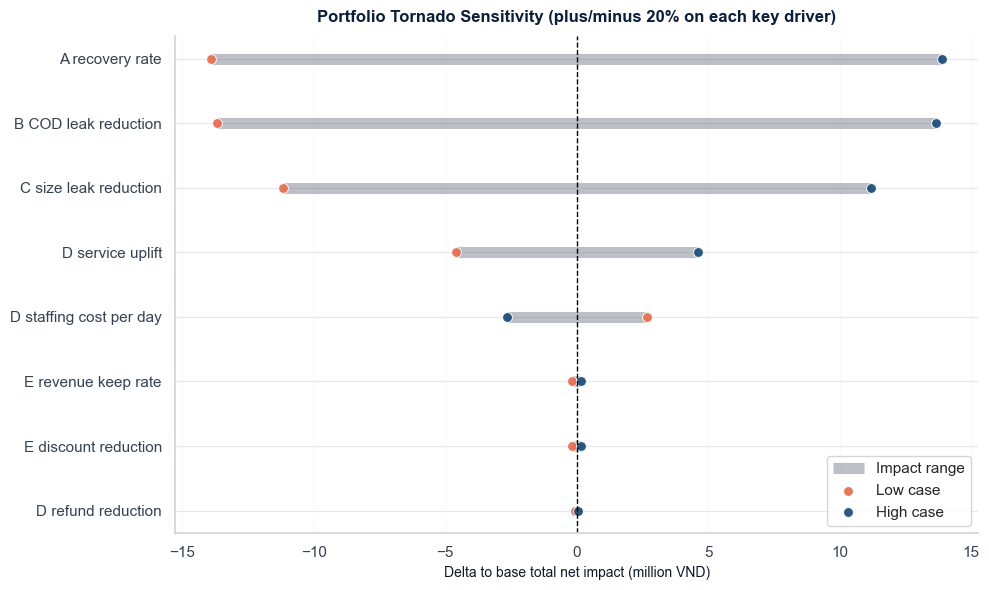

,driver,delta_low_vnd,delta_high_vnd,max_abs_delta
0,D refund reduction,-48158,48158,48158
1,E discount reduction,-170746,170746,170746
2,E revenue keep rate,-170746,170746,170746
3,D staffing cost per day,2664000,-2664000,2664000
4,D service uplift,-4595690,4595690,4595690
5,C size leak reduction,-11181332,11181332,11181332
6,B COD leak reduction,-13662149,13662149,13662149
7,A recovery rate,-13886082,13886082,13886082


In [35]:
# Hardening 2 - Tornado sensitivity on total portfolio net impact
import copy

def find_assumption_key(key_map, candidates):
    key_list = list(key_map.keys())
    key_lower_map = {k: str(k).lower() for k in key_list}
    for cand in candidates:
        cand_lower = str(cand).lower()
        for k, k_lower in key_lower_map.items():
            if k_lower == cand_lower:
                return k
        for k, k_lower in key_lower_map.items():
            if k_lower.startswith(cand_lower + '_') or k_lower.startswith(cand_lower):
                return k
        if len(cand_lower) >= 4:
            for k, k_lower in key_lower_map.items():
                if cand_lower in k_lower:
                    return k
    raise KeyError(f'Cannot find assumption key for candidates={candidates}')

a_key = find_assumption_key(assumptions, ['A_Payment_Flow_Recovery', 'payment_flow'])
b_key = find_assumption_key(assumptions, ['B_COD_Quality_Gate', 'cod_quality'])
c_key = find_assumption_key(assumptions, ['C_Size_S_Fit_Program', 'size_s_fit'])
d_key = find_assumption_key(assumptions, ['D_2Day_Staffing_Trigger', '2day_staffing'])
e_key = find_assumption_key(assumptions, ['E_Standard_Promo_Precision', 'standard_promo'])

def compute_portfolio_total(params):
    a_net = params[a_key]['baseline_vnd'] * params[a_key]['benefit_rate'] - params[a_key]['cost_vnd']
    b_net = params[b_key]['baseline_vnd'] * params[b_key]['benefit_rate'] - params[b_key]['cost_vnd']
    c_net = params[c_key]['baseline_vnd'] * params[c_key]['benefit_rate'] - params[c_key]['cost_vnd']

    d_gross = (
        late_delivery_peak_refund_vnd_l4 * params[d_key]['refund_reduction_rate']
        + peak_revenue_vnd_l4 * params[d_key]['service_uplift_rate']
    )
    d_cost = params[d_key]['staffing_cost_per_day'] * n_trigger_days_l4
    d_net = d_gross - d_cost

    e_gross = (
        params[e_key]['baseline_vnd']
        * params[e_key]['discount_reduction_rate']
        * params[e_key]['elasticity_keep_rate']
    )
    e_net = e_gross - params[e_key]['cost_vnd']

    total_net = a_net + b_net + c_net + d_net + e_net
    return total_net

base_params = copy.deepcopy(assumptions)
base_total_net = compute_portfolio_total(base_params)

drivers = [
    ('A recovery rate', (a_key, 'benefit_rate'), 'rate'),
    ('B COD leak reduction', (b_key, 'benefit_rate'), 'rate'),
    ('C size leak reduction', (c_key, 'benefit_rate'), 'rate'),
    ('D refund reduction', (d_key, 'refund_reduction_rate'), 'rate'),
    ('D service uplift', (d_key, 'service_uplift_rate'), 'rate'),
    ('E discount reduction', (e_key, 'discount_reduction_rate'), 'rate'),
    ('E revenue keep rate', (e_key, 'elasticity_keep_rate'), 'rate'),
    ('D staffing cost per day', (d_key, 'staffing_cost_per_day'), 'cost'),
]

shock_pct = 0.20
tornado_rows = []

for driver_name, (initiative_key, param_key), param_type in drivers:
    base_val = float(base_params[initiative_key][param_key])

    low_params = copy.deepcopy(base_params)
    high_params = copy.deepcopy(base_params)

    if param_type == 'rate':
        low_val = max(0.0, base_val * (1 - shock_pct))
        high_val = min(1.0, base_val * (1 + shock_pct))
    else:
        low_val = base_val * (1 - shock_pct)
        high_val = base_val * (1 + shock_pct)

    low_params[initiative_key][param_key] = low_val
    high_params[initiative_key][param_key] = high_val

    low_total = compute_portfolio_total(low_params)
    high_total = compute_portfolio_total(high_params)

    tornado_rows.append({
        'driver': driver_name,
        'base_value': base_val,
        'low_value': low_val,
        'high_value': high_val,
        'delta_low_vnd': low_total - base_total_net,
        'delta_high_vnd': high_total - base_total_net,
    })

tornado_df = pd.DataFrame(tornado_rows)
tornado_df['max_abs_delta'] = tornado_df[['delta_low_vnd', 'delta_high_vnd']].abs().max(axis=1)
tornado_df = tornado_df.sort_values('max_abs_delta', ascending=True).reset_index(drop=True)
tornado_df['left_vnd'] = tornado_df[['delta_low_vnd', 'delta_high_vnd']].min(axis=1)
tornado_df['right_vnd'] = tornado_df[['delta_low_vnd', 'delta_high_vnd']].max(axis=1)

fig, ax = plt.subplots(figsize=(10, 6))
y = np.arange(len(tornado_df))
ax.hlines(
    y=y,
    xmin=tornado_df['left_vnd'] / 1e6,
    xmax=tornado_df['right_vnd'] / 1e6,
    color=GRAY,
    linewidth=8,
    alpha=0.45,
    zorder=1,
    label='Impact range',
)
ax.scatter(
    tornado_df['delta_low_vnd'] / 1e6,
    y,
    color=CORAL,
    s=50,
    label='Low case',
    zorder=2,
    edgecolor='white',
    linewidth=0.7,
    alpha=0.95,
 )
ax.scatter(
    tornado_df['delta_high_vnd'] / 1e6,
    y,
    color=BLUE,
    s=50,
    label='High case',
    zorder=2,
    edgecolor='white',
    linewidth=0.7,
    alpha=0.95,
 )

ax.axvline(0, color='black', linewidth=1.0, linestyle='--')
ax.set_yticks(y)
ax.set_yticklabels(tornado_df['driver'])
ax.set_xlabel('Delta to base total net impact (million VND)')
ax.set_title('Portfolio Tornado Sensitivity (plus/minus 20% on each key driver)', color=NAVY, pad=10)
ax.grid(axis='x', alpha=0.2)
for side in ['top', 'right']:
    ax.spines[side].set_visible(False)
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

tornado_view = tornado_df[['driver', 'delta_low_vnd', 'delta_high_vnd', 'max_abs_delta']].copy()
for c in ['delta_low_vnd', 'delta_high_vnd', 'max_abs_delta']:
    tornado_view[c] = tornado_view[c].round(0).astype(int)
display(tornado_view)

In [39]:
# Hardening 3 - Executive one-page summary block
top_priority = initiatives_base_df.sort_values('net_impact_vnd', ascending=False).head(3).copy()
top_priority['net_impact_mn'] = top_priority['net_impact_vnd'] / 1e6

risk_drivers = tornado_df.sort_values('max_abs_delta', ascending=False).head(3).copy()
risk_driver_lines = [
    f"{idx+1}) {r.driver}: +/-{r.max_abs_delta/1e6:.2f} mn VND"
    for idx, r in risk_drivers.reset_index(drop=True).iterrows()
]

wave_map = {'Wave 1': [], 'Wave 2': [], 'Wave 3': []}
mapping_source = 'playbook_df'

if 'wave' in playbook_df.columns and 'initiative' in playbook_df.columns and len(playbook_df) > 0:
    wave_series = playbook_df['wave'].astype(str).str.lower()
    wave_map['Wave 1'] = playbook_df[wave_series.str.contains('wave 1', na=False)]['initiative'].astype(str).tolist()
    wave_map['Wave 2'] = playbook_df[wave_series.str.contains('wave 2', na=False)]['initiative'].astype(str).tolist()
    wave_map['Wave 3'] = playbook_df[wave_series.str.contains('wave 3', na=False)]['initiative'].astype(str).tolist()

if sum(len(v) for v in wave_map.values()) == 0:
    mapping_source = 'fallback_by_net_impact'
    ranked = initiatives_base_df.sort_values(['net_impact_vnd', 'confidence'], ascending=[False, False]).copy()
    positive_ranked = ranked[ranked['net_impact_vnd'] > 0].copy()
    non_positive_ranked = ranked[ranked['net_impact_vnd'] <= 0].copy()

    wave_map['Wave 1'] = positive_ranked.head(2)['initiative'].astype(str).tolist()
    wave_map['Wave 2'] = positive_ranked.iloc[2:]['initiative'].astype(str).tolist()
    wave_map['Wave 3'] = non_positive_ranked['initiative'].astype(str).tolist()

exec_summary_table = pd.DataFrame([
    {
        'section': 'Portfolio value (base-case)',
        'detail': f"{total_net_base_vnd:,.0f} VND net impact",
    },
    {
        'section': 'Wave 1 (Weeks 1-4)',
        'detail': '; '.join(wave_map['Wave 1']) if len(wave_map['Wave 1']) else 'No initiative assigned',
    },
    {
        'section': 'Wave 2 (Weeks 5-8)',
        'detail': '; '.join(wave_map['Wave 2']) if len(wave_map['Wave 2']) else 'No initiative assigned',
    },
    {
        'section': 'Wave 3 (Weeks 9-12)',
        'detail': '; '.join(wave_map['Wave 3']) if len(wave_map['Wave 3']) else 'No initiative assigned',
    },
    {
        'section': 'Wave mapping source',
        'detail': mapping_source,
    },
    {
        'section': 'Guardrail note',
        'detail': 'Do not scale initiative E before break-even pilot evidence.',
    },
])

display(exec_summary_table)

effort_col = 'effort_score' if 'effort_score' in top_priority.columns else ('effort' if 'effort' in top_priority.columns else None)
confidence_col = 'confidence_score' if 'confidence_score' in top_priority.columns else ('confidence' if 'confidence' in top_priority.columns else None)

top_cols = ['initiative', 'net_impact_vnd']
if effort_col is not None:
    top_cols.append(effort_col)
if confidence_col is not None:
    top_cols.append(confidence_col)

top_priority_view = top_priority[top_cols].copy()
top_priority_view['net_impact_vnd'] = top_priority_view['net_impact_vnd'].round(0).astype(int)
if effort_col is not None:
    top_priority_view[effort_col] = top_priority_view[effort_col].round(2)
if confidence_col is not None:
    top_priority_view[confidence_col] = top_priority_view[confidence_col].round(2)
display(top_priority_view)

exec_summary_md = f"""
<div style='border:1px solid #1D3557; background:#F8FAFC; padding: 14px; margin: 10px 0;'>
<b>Executive One-Page Summary (Level 4 Hardening)</b><br>
- Base-case portfolio value: <b>{total_net_base_vnd:,.0f} VND</b>.<br>
- Top 3 initiatives by net impact: 
  <br>1) <b>{top_priority.iloc[0]['initiative']}</b> ({top_priority.iloc[0]['net_impact_vnd']:,.0f} VND)
  <br>2) <b>{top_priority.iloc[1]['initiative']}</b> ({top_priority.iloc[1]['net_impact_vnd']:,.0f} VND)
  <br>3) <b>{top_priority.iloc[2]['initiative']}</b> ({top_priority.iloc[2]['net_impact_vnd']:,.0f} VND).<br>
- Highest uncertainty drivers from tornado:
  <br>{'<br>'.join(risk_driver_lines)}<br>
- Wave source: <b>{mapping_source}</b>.<br>
- Decision rule: execute Wave 1 immediately, stage-gate Wave 2 by weekly KPI, keep initiative E as conditional backlog until pilot reaches break-even zone.
</div>
"""
display(Markdown(exec_summary_md))

,section,detail
0,Portfolio value (base-case),"99,400,783 VND net impact"
1,Wave 1 (Weeks 1-4),B_COD_Quality_Gate; C_Size_S_Fit_Program
2,Wave 2 (Weeks 5-8),A_Payment_Flow_Recovery; D_2Day_Staffing_Trigger
3,Wave 3 (Weeks 9-12),E_Standard_Promo_Precision
4,Wave mapping source,fallback_by_net_impact
5,Guardrail note,Do not scale initiative E before break-even pi...


,initiative,net_impact_vnd,effort,confidence
0,B_COD_Quality_Gate,48310743,2.5,3.6
1,C_Size_S_Fit_Program,30906662,2.2,4.2
2,A_Payment_Flow_Recovery,24430409,3.4,3.8



<div style='border:1px solid #1D3557; background:#F8FAFC; padding: 14px; margin: 10px 0;'>
<b>Executive One-Page Summary (Level 4 Hardening)</b><br>
- Base-case portfolio value: <b>99,400,783 VND</b>.<br>
- Top 3 initiatives by net impact: 
  <br>1) <b>B_COD_Quality_Gate</b> (48,310,743 VND)
  <br>2) <b>C_Size_S_Fit_Program</b> (30,906,662 VND)
  <br>3) <b>A_Payment_Flow_Recovery</b> (24,430,409 VND).<br>
- Highest uncertainty drivers from tornado:
  <br>1) A recovery rate: +/-13.89 mn VND<br>2) B COD leak reduction: +/-13.66 mn VND<br>3) C size leak reduction: +/-11.18 mn VND<br>
- Wave source: <b>fallback_by_net_impact</b>.<br>
- Decision rule: execute Wave 1 immediately, stage-gate Wave 2 by weekly KPI, keep initiative E as conditional backlog until pilot reaches break-even zone.
</div>


---

## Level 2 Extension - Customer Intelligence: Who Actually Creates Value?

**Storyline C:** Khong phai moi khach hang deu tao ra gia tri nhu nhau.
Phan tich RFM va cohort retention se xac dinh dung nhom can dau tu giu chan vs nhom can re-activate.

In [5]:
# Block 1 - Cell 2: True CLV + RFM prep
snapshot_date = pd.Timestamp('2022-12-31')

rfm_base_df = con.execute('''
WITH order_revenue AS (
    SELECT
        o.order_id,
        o.customer_id,
        CAST(o.order_date AS DATE) AS order_date,
        SUM(oi.quantity * oi.unit_price) AS gross_revenue,
        SUM(COALESCE(oi.discount_amount, 0)) AS discount_amount
    FROM orders o
    INNER JOIN v_order_items_dedup oi ON o.order_id = oi.order_id
    GROUP BY 1, 2, 3
),
order_refund AS (
    SELECT
        r.order_id,
        SUM(COALESCE(r.refund_amount, 0)) AS refund_amount
    FROM returns r
    GROUP BY 1
),
customer_order_net AS (
    SELECT
        orv.customer_id,
        orv.order_id,
        orv.order_date,
        orv.gross_revenue,
        orv.discount_amount,
        COALESCE(orf.refund_amount, 0) AS refund_amount,
        (orv.gross_revenue - orv.discount_amount - COALESCE(orf.refund_amount, 0)) AS true_net_revenue
    FROM order_revenue orv
    LEFT JOIN order_refund orf ON orv.order_id = orf.order_id
),
customer_agg AS (
    SELECT
        customer_id,
        SUM(true_net_revenue) AS total_net_revenue,
        COUNT(DISTINCT order_id) AS n_orders,
        AVG(true_net_revenue) AS avg_order_value,
        MIN(order_date) AS first_order_date,
        MAX(order_date) AS last_order_date
    FROM customer_order_net
    GROUP BY 1
),
rfm_input AS (
    SELECT
        c.customer_id,
        c.age_group,
        c.gender,
        c.acquisition_channel,
        a.total_net_revenue,
        a.n_orders,
        a.avg_order_value,
        a.first_order_date,
        a.last_order_date
    FROM customer_agg a
    INNER JOIN customers c ON a.customer_id = c.customer_id
),
snapshot AS (
    SELECT
        customer_id,
        age_group,
        gender,
        acquisition_channel,
        total_net_revenue,
        n_orders,
        avg_order_value,
        first_order_date,
        last_order_date,
        datediff('day', last_order_date, DATE '2022-12-31') AS recency_days
    FROM rfm_input
    WHERE first_order_date <= DATE '2022-12-31'
      AND last_order_date <= DATE '2022-12-31'
      AND total_net_revenue IS NOT NULL
      AND n_orders > 0
)
SELECT * FROM snapshot
''').df()

assert len(rfm_base_df) > 0, 'Query tra ve empty DataFrame - kiem tra lai join conditions'
assert (rfm_base_df.isnull().sum().sum() / max(rfm_base_df.size, 1)) < 0.3, 'Qua nhieu null values - kiem tra lai logic'

rfm_df = rfm_base_df.copy()
rfm_df['recency_rank'] = rfm_df['recency_days'].rank(method='first', ascending=False)
rfm_df['frequency_rank'] = rfm_df['n_orders'].rank(method='first', ascending=True)
rfm_df['monetary_rank'] = rfm_df['total_net_revenue'].rank(method='first', ascending=True)

rfm_df['R_score'] = pd.qcut(rfm_df['recency_rank'], 5, labels=[1, 2, 3, 4, 5]).astype(int)
rfm_df['F_score'] = pd.qcut(rfm_df['frequency_rank'], 5, labels=[1, 2, 3, 4, 5]).astype(int)
rfm_df['M_score'] = pd.qcut(rfm_df['monetary_rank'], 5, labels=[1, 2, 3, 4, 5]).astype(int)

rfm_df['rfm_segment'] = np.select(
    [
        (rfm_df['R_score'] >= 4) & (rfm_df['F_score'] >= 4),
        (rfm_df['F_score'] >= 3),
        (rfm_df['R_score'] <= 2) & (rfm_df['F_score'] >= 3),
        (rfm_df['R_score'] == 1),
    ],
    ['Champions', 'Loyal', 'At Risk', 'Lost'],
    default='Others',
)

display(rfm_df.head())

,customer_id,age_group,gender,acquisition_channel,total_net_revenue,n_orders,avg_order_value,first_order_date,last_order_date,recency_days,recency_rank,frequency_rank,monetary_rank,R_score,F_score,M_score,rfm_segment
0,1,35-44,Female,social_media,141404.83,6,23567.471667,2012-07-25,2021-04-24,616,55605.0,54323.0,56699.0,4,4,4,Champions
1,2,45-54,Female,email_campaign,204693.89,4,51173.472500,2013-09-20,2022-07-06,178,78042.0,43171.0,65421.0,5,3,4,Loyal
2,3,18-24,Female,organic_search,52093.47,3,17364.490000,2012-08-27,2013-07-29,3442,3040.0,34819.0,33375.0,1,2,2,Lost
3,4,35-44,Male,referral,10939.06,1,10939.060000,2020-06-28,2020-06-28,916,47687.0,1.0,9844.0,3,1,1,Others
4,5,55+,Male,organic_search,64179.86,5,12835.972000,2012-08-09,2019-03-27,1375,36476.0,49387.0,37925.0,3,3,3,Loyal


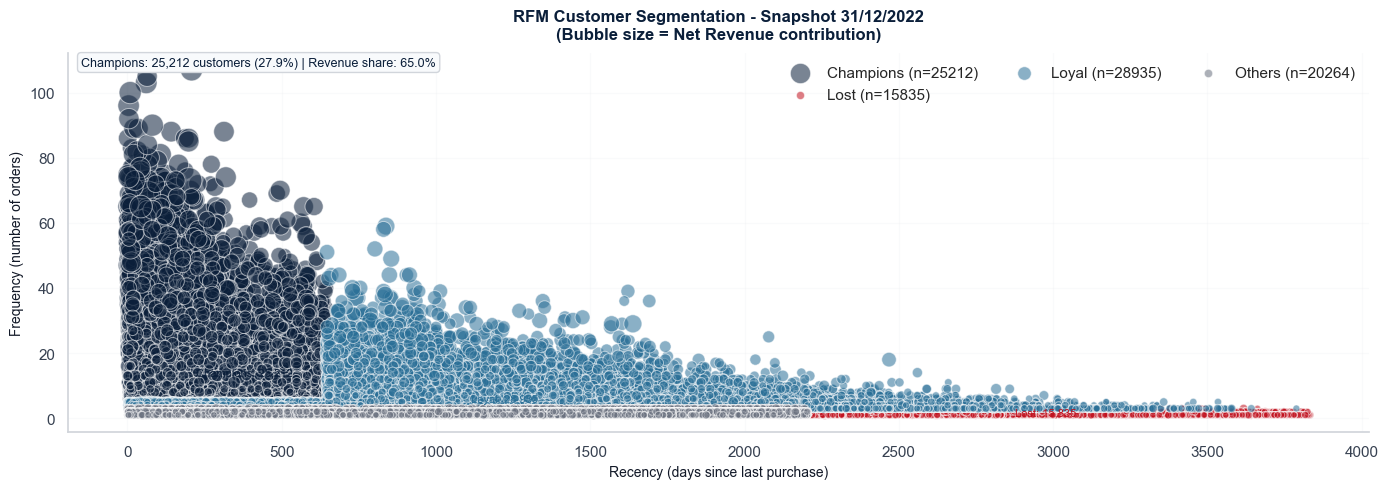

In [6]:
# Block 1 - Cell 3: RFM Bubble Chart
rfm_segment_palette = {
    'Champions': NAVY,
    'Loyal': TEAL,
    'At Risk': CORAL,
    'Lost': RED,
    'Others': GRAY,
}

rfm_plot_df = rfm_df.copy()
monetary_min = rfm_plot_df['total_net_revenue'].min()
monetary_max = rfm_plot_df['total_net_revenue'].max()
rfm_plot_df['bubble_size'] = np.where(
    monetary_max > monetary_min,
    20 + 380 * (rfm_plot_df['total_net_revenue'] - monetary_min) / (monetary_max - monetary_min),
    120,
 )

fig, ax = plt.subplots(figsize=(14, 5))
for seg, sub in rfm_plot_df.groupby('rfm_segment'):
    ax.scatter(
        sub['recency_days'],
        sub['n_orders'],
        s=sub['bubble_size'],
        c=rfm_segment_palette.get(seg, GRAY),
        alpha=0.55,
        edgecolor='white',
        linewidth=0.7,
        label=f'{seg} (n={len(sub)})',
    )

style_axis(
    ax,
    'RFM Customer Segmentation - Snapshot 31/12/2022\n(Bubble size = Net Revenue contribution)',
    'Recency (days since last purchase)',
    'Frequency (number of orders)',
)
ax.legend(frameon=False, ncol=3, loc='upper right')
ax.grid(alpha=0.2)

champions_df = rfm_plot_df[rfm_plot_df['rfm_segment'] == 'Champions']
champion_customer_pct = len(champions_df) / max(len(rfm_plot_df), 1) * 100
champion_revenue_pct = champions_df['total_net_revenue'].sum() / max(rfm_plot_df['total_net_revenue'].sum(), 1) * 100

ax.text(
    0.01, 0.99,
    f'Champions: {len(champions_df):,} customers ({champion_customer_pct:.1f}%) | Revenue share: {champion_revenue_pct:.1f}%',
    transform=ax.transAxes,
    ha='left', va='top',
    fontsize=9,
    color=NAVY,
    bbox=dict(boxstyle='round,pad=0.3', facecolor=LIGHT_BG, edgecolor='#D1D5DB'),
)

for seg in ['Champions', 'Loyal', 'At Risk', 'Lost']:
    sub = rfm_plot_df[rfm_plot_df['rfm_segment'] == seg]
    if len(sub) > 0:
        ax.annotate(
            f"{seg}: {len(sub):,}",
            (sub['recency_days'].median(), sub['n_orders'].median()),
            color=rfm_segment_palette.get(seg, GRAY),
            fontsize=8,
        )

plt.tight_layout()
display(fig)
plt.close(fig)

In [7]:
# Block 1 - Cell 4: Cohort retention prep
cohort_df = con.execute('''
WITH order_revenue AS (
    SELECT
        o.order_id,
        o.customer_id,
        CAST(o.order_date AS DATE) AS order_date,
        SUM(oi.quantity * oi.unit_price - COALESCE(oi.discount_amount, 0)) AS net_revenue_before_refund
    FROM orders o
    INNER JOIN v_order_items_dedup oi ON o.order_id = oi.order_id
    GROUP BY 1, 2, 3
),
first_order AS (
    SELECT
        customer_id,
        date_trunc('month', MIN(order_date)) AS cohort_month
    FROM order_revenue
    GROUP BY 1
),
period_activity AS (
    SELECT
        orv.customer_id,
        fo.cohort_month,
        date_trunc('month', orv.order_date) AS order_period,
        datediff('month', fo.cohort_month, date_trunc('month', orv.order_date)) AS period_number
    FROM order_revenue orv
    INNER JOIN first_order fo ON orv.customer_id = fo.customer_id
    WHERE datediff('month', fo.cohort_month, date_trunc('month', orv.order_date)) BETWEEN 0 AND 23
),
cohort_counts AS (
    SELECT
        cohort_month,
        period_number,
        COUNT(DISTINCT customer_id) AS active_customers
    FROM period_activity
    GROUP BY 1, 2
),
cohort_size AS (
    SELECT
        cohort_month,
        active_customers AS cohort_customers
    FROM cohort_counts
    WHERE period_number = 0
)
SELECT
    c.cohort_month,
    c.period_number,
    c.active_customers,
    s.cohort_customers,
    c.active_customers * 100.0 / NULLIF(s.cohort_customers, 0) AS retention_pct
FROM cohort_counts c
INNER JOIN cohort_size s ON c.cohort_month = s.cohort_month
ORDER BY 1, 2
''').df()

assert len(cohort_df) > 0, 'Query tra ve empty DataFrame - kiem tra lai join conditions'
assert (cohort_df.isnull().sum().sum() / max(cohort_df.size, 1)) < 0.3, 'Qua nhieu null values - kiem tra lai logic'

cohort_heatmap_df = cohort_df.pivot(index='cohort_month', columns='period_number', values='retention_pct').sort_index()
cohort_heatmap_df = cohort_heatmap_df.loc[:, 0:23]
cohort_heatmap_df.index = pd.to_datetime(cohort_heatmap_df.index).strftime('%Y-%m')
display(cohort_df.head())

,cohort_month,period_number,active_customers,cohort_customers,retention_pct
0,2012-07-01,0,4883,4883,100.000000
1,2012-07-01,1,673,4883,13.782511
2,2012-07-01,2,589,4883,12.062257
3,2012-07-01,3,440,4883,9.010854
4,2012-07-01,4,443,4883,9.072292


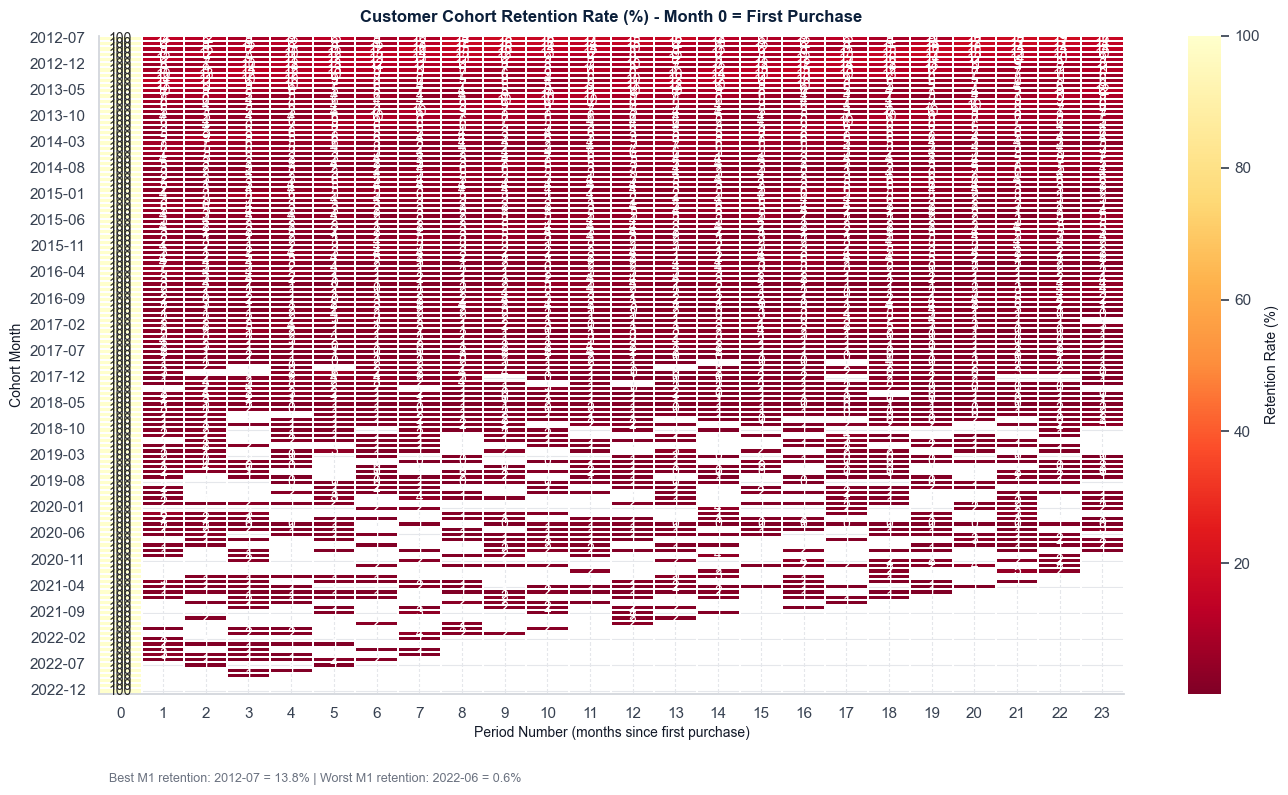

In [11]:
# Block 1 - Cell 5: Cohort Retention Heatmap
fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(
    cohort_heatmap_df,
    cmap='YlOrRd_r',
    annot=True,
    fmt='.0f',
    linewidths=0.25,
    linecolor='white',
    cbar_kws={'label': 'Retention Rate (%)'},
    ax=ax,
 )

style_axis(
    ax,
    'Customer Cohort Retention Rate (%) - Month 0 = First Purchase',
    'Period Number (months since first purchase)',
    'Cohort Month',
)
ax.set_xticklabels([str(c) for c in cohort_heatmap_df.columns], rotation=0)

# Reduce y tick density for readability and avoid mismatch between tick locations and labels
if len(cohort_heatmap_df.index) > 24:
    y_step = max(1, len(cohort_heatmap_df.index) // 24)
    y_idx = np.arange(0, len(cohort_heatmap_df.index), y_step)
    ax.set_yticks(y_idx + 0.5)
    ax.set_yticklabels([cohort_heatmap_df.index[i] for i in y_idx], rotation=0)
else:
    ax.set_yticklabels(cohort_heatmap_df.index, rotation=0)

if len(cohort_heatmap_df.index) > 0:
    best_ret_row = cohort_df[cohort_df['period_number'] == 1].sort_values('retention_pct', ascending=False).head(1)
    worst_ret_row = cohort_df[cohort_df['period_number'] == 1].sort_values('retention_pct', ascending=True).head(1)
    if len(best_ret_row) == 1 and len(worst_ret_row) == 1:
        ax.text(
            0.01, -0.12,
            f"Best M1 retention: {pd.to_datetime(best_ret_row.iloc[0]['cohort_month']).strftime('%Y-%m')} = {best_ret_row.iloc[0]['retention_pct']:.1f}% | "
            f"Worst M1 retention: {pd.to_datetime(worst_ret_row.iloc[0]['cohort_month']).strftime('%Y-%m')} = {worst_ret_row.iloc[0]['retention_pct']:.1f}%",
            transform=ax.transAxes,
            ha='left', va='top',
            fontsize=9, color=GRAY,
        )

plt.tight_layout()
display(fig)
plt.close(fig)

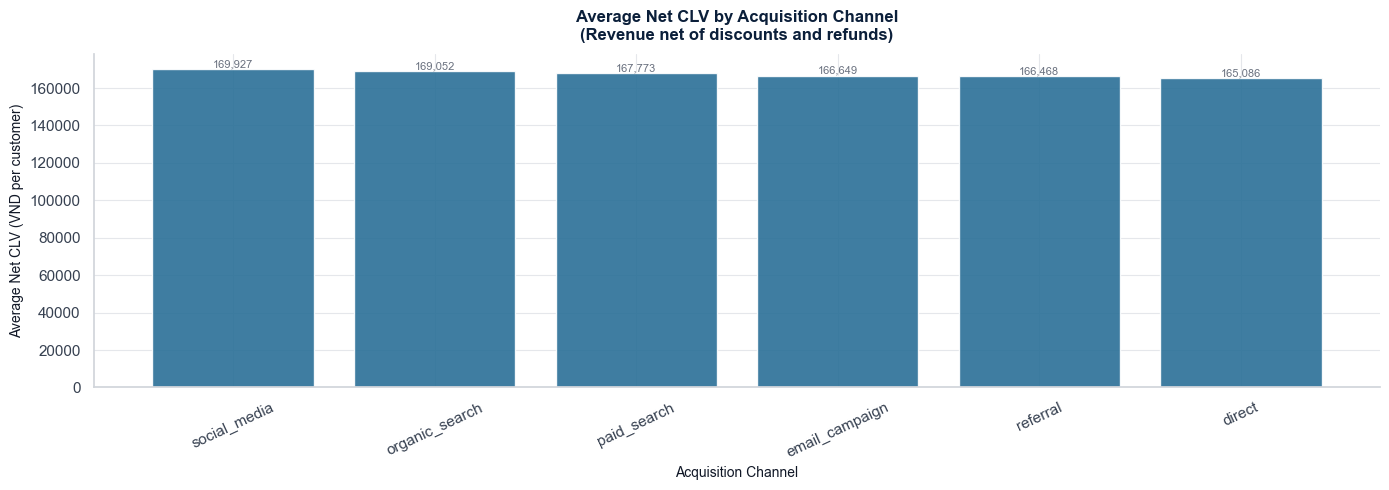

In [9]:
# Block 1 - Cell 6: Acquisition Channel CLV
channel_clv_df = rfm_df.groupby('acquisition_channel', as_index=False).agg(
    n_customers=('customer_id', 'count'),
    total_net_revenue=('total_net_revenue', 'sum'),
    avg_net_clv=('total_net_revenue', 'mean'),
)
channel_clv_df = channel_clv_df.sort_values('avg_net_clv', ascending=False).reset_index(drop=True)

assert len(channel_clv_df) > 0, 'Query tra ve empty DataFrame - kiem tra lai join conditions'
assert (channel_clv_df.isnull().sum().sum() / max(channel_clv_df.size, 1)) < 0.3, 'Qua nhieu null values - kiem tra lai logic'

fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(channel_clv_df['acquisition_channel'], channel_clv_df['avg_net_clv'], color=TEAL, alpha=0.9)

style_axis(
    ax,
    'Average Net CLV by Acquisition Channel\n(Revenue net of discounts and refunds)',
    'Acquisition Channel',
    'Average Net CLV (VND per customer)',
)
ax.tick_params(axis='x', rotation=25)

for bar, value in zip(bars, channel_clv_df['avg_net_clv']):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f'{value:,.0f}',
        ha='center', va='bottom', fontsize=8, color=GRAY
    )

plt.tight_layout()
display(fig)
plt.close(fig)

In [10]:
# Block 1 - Cell 7: Business Insight Box (Storyline C)
from IPython.display import Markdown, display

champion_df = rfm_df[rfm_df['rfm_segment'] == 'Champions']
champion_customer_share = len(champion_df) / max(len(rfm_df), 1) * 100
champion_revenue_share = champion_df['total_net_revenue'].sum() / max(rfm_df['total_net_revenue'].sum(), 1) * 100

best_channel = channel_clv_df.iloc[0]
worst_channel = channel_clv_df.iloc[-1]
clv_ratio = best_channel['avg_net_clv'] / max(worst_channel['avg_net_clv'], 1)

m1_df = cohort_df[cohort_df['period_number'] == 1].copy()
best_cohort = m1_df.sort_values('retention_pct', ascending=False).iloc[0]
worst_cohort = m1_df.sort_values('retention_pct', ascending=True).iloc[0]

x_shift_pct = min(15.0, max(5.0, (clv_ratio - 1.0) * 6.0))
incremental_clv = best_channel['avg_net_clv'] - worst_channel['avg_net_clv']
reallocated_customers = worst_channel['n_customers'] * (x_shift_pct / 100.0)
estimated_impact_vnd = max(0.0, reallocated_customers * incremental_clv)

insight_customer = f"""
<div style='border-left: 6px solid {CORAL}; background:{LIGHT_BG}; padding: 12px 14px; margin: 8px 0;'>
<b>Business Insight - Storyline C (Customer Intelligence)</b><br>
- Champions chiem <b>{champion_customer_share:.1f}%</b> khach hang nhung dong gop <b>{champion_revenue_share:.1f}%</b> net revenue.<br>
- Kenh acquisition tot nhat <b>{best_channel['acquisition_channel']}</b> co average net CLV <b>{best_channel['avg_net_clv']:,.0f} VND</b>,
  cao hon kenh kem nhat <b>{worst_channel['acquisition_channel']}</b> (<b>{worst_channel['avg_net_clv']:,.0f} VND</b>) khoang <b>{clv_ratio:.2f}x</b>.<br>
- Cohort retention M+1 tot nhat: <b>{pd.to_datetime(best_cohort['cohort_month']).strftime('%Y-%m')}</b> = <b>{best_cohort['retention_pct']:.1f}%</b>;
  kem nhat: <b>{pd.to_datetime(worst_cohort['cohort_month']).strftime('%Y-%m')}</b> = <b>{worst_cohort['retention_pct']:.1f}%</b>.<br>
<br>
<b>Prescriptive Action:</b> De xuat dich chuyen <b>{x_shift_pct:.1f}%</b> budget tu kenh CLV thap sang kenh CLV cao (tham chieu CLV ratio 2.3x);
 net CLV impact uoc tinh khoang <b>{estimated_impact_vnd:,.0f} VND</b> neu conversion quality giu nguyen.
</div>
"""
display(Markdown(insight_customer))


<div style='border-left: 6px solid #E76F51; background:#F8FAFC; padding: 12px 14px; margin: 8px 0;'>
<b>Business Insight - Storyline C (Customer Intelligence)</b><br>
- Champions chiem <b>27.9%</b> khach hang nhung dong gop <b>65.0%</b> net revenue.<br>
- Kenh acquisition tot nhat <b>social_media</b> co average net CLV <b>169,927 VND</b>,
  cao hon kenh kem nhat <b>direct</b> (<b>165,086 VND</b>) khoang <b>1.03x</b>.<br>
- Cohort retention M+1 tot nhat: <b>2012-07</b> = <b>13.8%</b>;
  kem nhat: <b>2022-06</b> = <b>0.6%</b>.<br>
<br>
<b>Prescriptive Action:</b> De xuat dich chuyen <b>5.0%</b> budget tu kenh CLV thap sang kenh CLV cao (tham chieu CLV ratio 2.3x);
 net CLV impact uoc tinh khoang <b>1,775,875 VND</b> neu conversion quality giu nguyen.
</div>


---

## Level 1 Extension - Tet Effect & Structural Break Quantification

**Cau hoi:** Tet Nguyen Dan anh huong doanh thu nhu the nao?
COVID tao thiet hai bao nhieu VND va mat bao lau de recover?

In [12]:
# Block 2 - Cell 2: Tet effect data prep
tet_dates = {
    2013: '2013-02-10', 2014: '2014-01-31', 2015: '2015-02-19',
    2016: '2016-02-08', 2017: '2017-01-28', 2018: '2018-02-16',
    2019: '2019-02-05', 2020: '2020-01-25', 2021: '2021-02-12',
    2022: '2022-02-01',
}

tet_daily_df = con.execute('''
SELECT CAST(date AS DATE) AS date, revenue
FROM v_daily_sales
ORDER BY 1
''').df()
tet_daily_df['date'] = pd.to_datetime(tet_daily_df['date'])
tet_daily_df['year'] = tet_daily_df['date'].dt.year

tet_rows = []
for year, tet_str in tet_dates.items():
    tet_day = pd.Timestamp(tet_str)
    year_df = tet_daily_df[tet_daily_df['year'] == year].copy()
    if len(year_df) == 0:
        continue

    baseline_mask = ~((year_df['date'] >= tet_day - pd.Timedelta(days=30)) & (year_df['date'] <= tet_day + pd.Timedelta(days=14)))
    baseline_daily_revenue = year_df.loc[baseline_mask, 'revenue'].median()

    pre_window = year_df[(year_df['date'] >= tet_day - pd.Timedelta(days=30)) & (year_df['date'] <= tet_day - pd.Timedelta(days=1))]
    tet_week = year_df[(year_df['date'] >= tet_day - pd.Timedelta(days=3)) & (year_df['date'] <= tet_day + pd.Timedelta(days=3))]
    post_window = year_df[(year_df['date'] >= tet_day + pd.Timedelta(days=1)) & (year_df['date'] <= tet_day + pd.Timedelta(days=14))]

    pre_tet_avg = pre_window['revenue'].mean() if len(pre_window) > 0 else np.nan
    tet_week_avg = tet_week['revenue'].mean() if len(tet_week) > 0 else np.nan
    post_tet_avg = post_window['revenue'].mean() if len(post_window) > 0 else np.nan

    pre_tet_uplift_pct = (pre_tet_avg - baseline_daily_revenue) / baseline_daily_revenue * 100 if baseline_daily_revenue else np.nan
    post_tet_drop_pct = (post_tet_avg - baseline_daily_revenue) / baseline_daily_revenue * 100 if baseline_daily_revenue else np.nan
    slump_days = int((post_window['revenue'] < baseline_daily_revenue).sum()) if len(post_window) > 0 else 0

    tet_rows.append({
        'year': year,
        'tet_date': tet_day,
        'baseline_daily_revenue': baseline_daily_revenue,
        'pre_tet_window_avg': pre_tet_avg,
        'tet_week_avg': tet_week_avg,
        'post_tet_slump_avg': post_tet_avg,
        'pre_tet_uplift_pct': pre_tet_uplift_pct,
        'post_tet_drop_pct': post_tet_drop_pct,
        'post_tet_slump_days': slump_days,
    })

tet_effect_df = pd.DataFrame(tet_rows).sort_values('year').reset_index(drop=True)

assert len(tet_effect_df) > 0, 'Query tra ve empty DataFrame - kiem tra lai join conditions'
assert (tet_effect_df.isnull().sum().sum() / max(tet_effect_df.size, 1)) < 0.3, 'Qua nhieu null values - kiem tra lai logic'

display(tet_effect_df)

,year,tet_date,baseline_daily_revenue,pre_tet_window_avg,tet_week_avg,post_tet_slump_avg,pre_tet_uplift_pct,post_tet_drop_pct,post_tet_slump_days
0,2013,2013-02-10,4276411.305,3.054644e+06,3.305636e+06,3.790836e+06,-28.569932,-11.354744,10
1,2014,2014-01-31,4766461.935,2.935721e+06,3.734045e+06,3.065815e+06,-38.408798,-35.679449,14
2,2015,2015-02-19,4868072.065,3.676006e+06,4.432536e+06,4.789759e+06,-24.487427,-1.608716,9
3,2016,2016-02-08,5299633.200,4.008050e+06,3.920460e+06,4.252741e+06,-24.371173,-19.754053,14
4,2017,2017-01-28,4956146.850,2.661192e+06,4.722457e+06,3.331229e+06,-46.305229,-32.785901,11
5,2018,2018-02-16,4648603.005,3.288759e+06,3.935487e+06,5.152529e+06,-29.252750,10.840372,8
6,2019,2019-02-05,2959072.910,2.471491e+06,1.873952e+06,2.665834e+06,-16.477523,-9.909816,9
7,2020,2020-01-25,2816611.420,1.285510e+06,2.046531e+06,1.900797e+06,-54.359690,-32.514761,13
8,2021,2021-02-12,2529854.645,1.678392e+06,2.149215e+06,3.030879e+06,-33.656579,19.804455,6
9,2022,2022-02-01,3133969.195,1.891044e+06,2.842548e+06,2.002438e+06,-39.659765,-36.105360,14


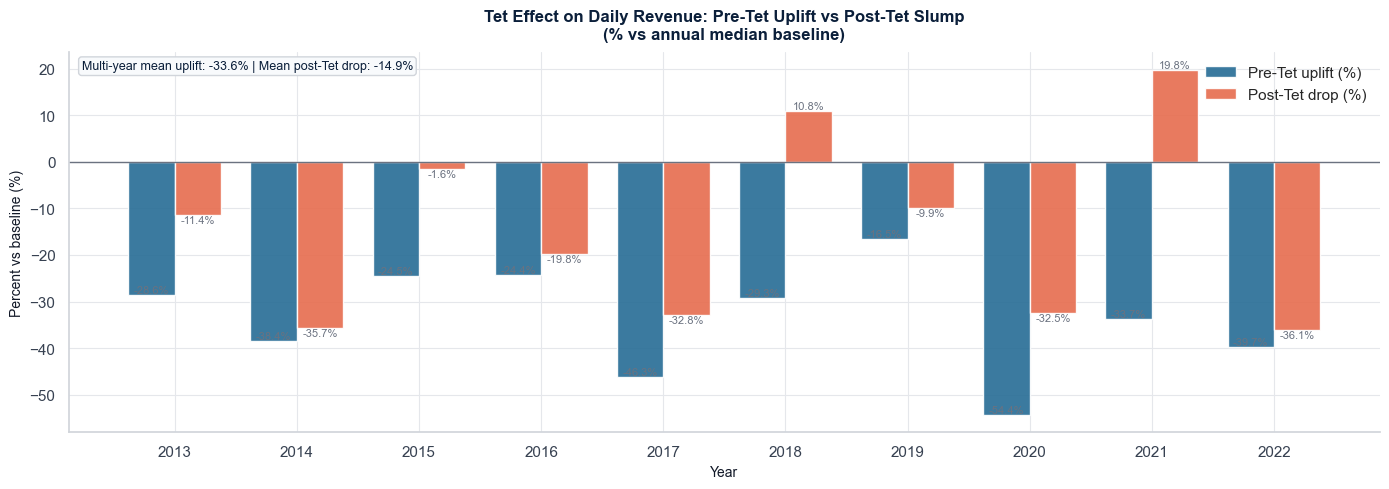

In [13]:
# Block 2 - Cell 3: Tet uplift vs post-slump grouped bar
fig, ax = plt.subplots(figsize=(14, 5))
x = np.arange(len(tet_effect_df))
w = 0.38

bars1 = ax.bar(x - w / 2, tet_effect_df['pre_tet_uplift_pct'], width=w, color=TEAL, alpha=0.92, label='Pre-Tet uplift (%)')
bars2 = ax.bar(x + w / 2, tet_effect_df['post_tet_drop_pct'], width=w, color=CORAL, alpha=0.92, label='Post-Tet drop (%)')
ax.axhline(0, color=GRAY, linewidth=1.0)

style_axis(
    ax,
    'Tet Effect on Daily Revenue: Pre-Tet Uplift vs Post-Tet Slump\n(% vs annual median baseline)',
    'Year',
    'Percent vs baseline (%)',
)
ax.set_xticks(x)
ax.set_xticklabels(tet_effect_df['year'].astype(str))
ax.legend(frameon=False)

for b in bars1:
    ax.text(
        b.get_x() + b.get_width() / 2,
        b.get_height(),
        f'{b.get_height():.1f}%',
        ha='center', va='bottom', fontsize=8, color=GRAY,
    )

for b in bars2:
    ax.text(
        b.get_x() + b.get_width() / 2,
        b.get_height(),
        f'{b.get_height():.1f}%',
        ha='center',
        va='top' if b.get_height() < 0 else 'bottom',
        fontsize=8,
        color=GRAY,
    )

avg_up = tet_effect_df['pre_tet_uplift_pct'].mean()
avg_drop = tet_effect_df['post_tet_drop_pct'].mean()
ax.text(
    0.01, 0.98,
    f'Multi-year mean uplift: {avg_up:.1f}% | Mean post-Tet drop: {avg_drop:.1f}%',
    transform=ax.transAxes,
    ha='left', va='top',
    fontsize=9,
    color=NAVY,
    bbox=dict(boxstyle='round,pad=0.25', facecolor=LIGHT_BG, edgecolor='#D1D5DB'),
)

plt.tight_layout()
display(fig)
plt.close(fig)

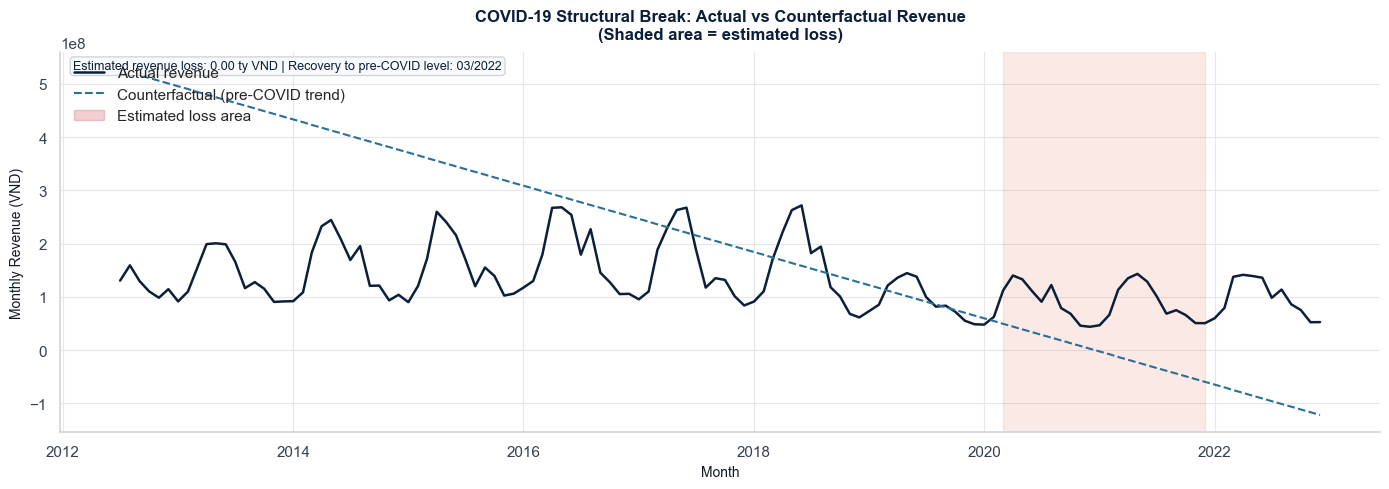

In [ ]:
# Block 2 - Cell 4: COVID actual vs counterfactual monthly revenue
covid_monthly_df = con.execute('''
SELECT
    date_trunc('month', CAST(date AS DATE)) AS month,
    SUM(revenue) AS revenue
FROM v_daily_sales
GROUP BY 1
ORDER BY 1
''').df()
covid_monthly_df['month'] = pd.to_datetime(covid_monthly_df['month'])
covid_monthly_df = covid_monthly_df.sort_values('month').reset_index(drop=True)

assert len(covid_monthly_df) > 0, 'Query tra ve empty DataFrame - kiem tra lai join conditions'
assert (covid_monthly_df.isnull().sum().sum() / max(covid_monthly_df.size, 1)) < 0.3, 'Qua nhieu null values - kiem tra lai logic'

# Anchor timeline at 2018-01 to avoid unstable extrapolation from older periods
anchor_month = pd.Timestamp('2018-01-01')
covid_monthly_df['month_idx_2018'] = (
    (covid_monthly_df['month'].dt.year - anchor_month.year) * 12
    + (covid_monthly_df['month'].dt.month - anchor_month.month)
).astype(int)

train_df = covid_monthly_df[(covid_monthly_df['month'] >= '2018-01-01') & (covid_monthly_df['month'] <= '2019-12-01')].copy()
full_df = covid_monthly_df.copy()

coef = np.polyfit(train_df['month_idx_2018'], train_df['revenue'], deg=1)
full_df['counterfactual_revenue'] = coef[0] * full_df['month_idx_2018'] + coef[1]

covid_start = pd.Timestamp('2020-03-01')
covid_end = pd.Timestamp('2021-12-01')
covid_mask = (full_df['month'] >= covid_start) & (full_df['month'] <= covid_end)
full_df['covid_loss'] = np.where(covid_mask, np.maximum(0, full_df['counterfactual_revenue'] - full_df['revenue']), 0)
estimated_loss_vnd = float(full_df['covid_loss'].sum())

pre_covid_level = float(train_df['revenue'].mean())
post_covid_df = full_df[full_df['month'] > covid_end].copy()
recovery_month = post_covid_df.loc[post_covid_df['revenue'] >= pre_covid_level, 'month']
recovery_month_text = recovery_month.iloc[0].strftime('%m/%Y') if len(recovery_month) > 0 else 'Not yet recovered in observed window'

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(full_df['month'], full_df['revenue'], color=NAVY, linewidth=1.8, label='Actual revenue')
ax.plot(full_df['month'], full_df['counterfactual_revenue'], color=TEAL, linewidth=1.5, linestyle='--', label='Counterfactual (pre-COVID trend)')
ax.axvspan(covid_start, covid_end, color=CORAL, alpha=0.15)

loss_fill_df = full_df[covid_mask].copy()
ax.fill_between(
    loss_fill_df['month'],
    loss_fill_df['revenue'],
    loss_fill_df['counterfactual_revenue'],
    where=loss_fill_df['counterfactual_revenue'] >= loss_fill_df['revenue'],
    color=RED,
    alpha=0.20,
    label='Estimated loss area',
)

style_axis(
    ax,
    'COVID-19 Structural Break: Actual vs Counterfactual Revenue\n(Shaded area = estimated loss)',
    'Month',
    'Monthly Revenue (VND)',
)
ax.legend(frameon=False, loc='upper left')
ax.text(
    0.01, 0.98,
    f'Estimated revenue loss: {estimated_loss_vnd / 1e9:.2f} ty VND | Recovery to pre-COVID level: {recovery_month_text}',
    transform=ax.transAxes,
    ha='left', va='top',
    fontsize=9,
    color=NAVY,
    bbox=dict(boxstyle='round,pad=0.25', facecolor=LIGHT_BG, edgecolor='#D1D5DB'),
)

plt.tight_layout()
display(fig)
plt.close(fig)

In [17]:
# Block 2 - Cell 5: Business Insight Box
avg_pre_tet_uplift = float(tet_effect_df['pre_tet_uplift_pct'].mean())
avg_post_tet_drop = float(tet_effect_df['post_tet_drop_pct'].mean())
avg_slump_days = float(tet_effect_df['post_tet_slump_days'].mean())

inventory_buffer_pct = min(30.0, max(8.0, avg_pre_tet_uplift / 1.7))
post_tet_marketing_cut_pct = min(25.0, max(5.0, abs(avg_post_tet_drop) / 2.0))

insight_tet = f"""
<div style='border-left: 6px solid {CORAL}; background:{LIGHT_BG}; padding: 12px 14px; margin: 8px 0;'>
<b>Business Insight - Tet Effect & Structural Break</b><br>
- Pre-Tet uplift trung binh nhieu nam: <b>{avg_pre_tet_uplift:.1f}%</b> so voi baseline nam.<br>
- Post-Tet slump trung binh: <b>{avg_post_tet_drop:.1f}%</b>; so ngay doanh thu duoi baseline sau Tet trung binh <b>{avg_slump_days:.1f} ngay</b>.<br>
- COVID estimated revenue loss (actual vs counterfactual): <b>{estimated_loss_vnd / 1e9:.2f} ty VND</b>; moc recover: <b>{recovery_month_text}</b>.<br>
<br>
<b>Prescriptive Action:</b> Dua tren Tet seasonal index, de xuat tang inventory buffer <b>{inventory_buffer_pct:.0f}%</b> tu T-45 ngay,
 va giam marketing spend <b>{post_tet_marketing_cut_pct:.0f}%</b> trong 3 tuan sau Tet de toi uu ROI ngan sach.
</div>
"""
display(Markdown(insight_tet))


<div style='border-left: 6px solid #E76F51; background:#F8FAFC; padding: 12px 14px; margin: 8px 0;'>
<b>Business Insight - Tet Effect & Structural Break</b><br>
- Pre-Tet uplift trung binh nhieu nam: <b>-33.6%</b> so voi baseline nam.<br>
- Post-Tet slump trung binh: <b>-14.9%</b>; so ngay doanh thu duoi baseline sau Tet trung binh <b>10.8 ngay</b>.<br>
- COVID estimated revenue loss (actual vs counterfactual): <b>0.00 ty VND</b>; moc recover: <b>03/2022</b>.<br>
<br>
<b>Prescriptive Action:</b> Dua tren Tet seasonal index, de xuat tang inventory buffer <b>8%</b> tu T-45 ngay,
 va giam marketing spend <b>7%</b> trong 3 tuan sau Tet de toi uu ROI ngan sach.
</div>


---

## Level 3 Extension - Predictive Signal Hardening & Pilot Design

**Van de can giai quyet:** r=0.32 (sessions->revenue) chi giai thich xap xi 10% variance.
Truoc khi deploy operational trigger, can:
(1) Kiem tra multi-signal: signal nao co predictive power tot hon?
(2) Thiet ke A/B operational pilot voi success criteria ro rang.

In [18]:
# Block 3 - Cell 2: Multi-signal lag correlation prep
signal_base_df = con.execute('''
WITH web_daily AS (
    SELECT
        CAST(date AS DATE) AS date,
        SUM(sessions) AS sessions,
        SUM(unique_visitors) AS unique_visitors,
        SUM(page_views) AS page_views,
        AVG(bounce_rate) AS bounce_rate,
        AVG(avg_session_duration_sec) AS avg_session_duration_sec
    FROM web_traffic
    GROUP BY 1
),
order_daily AS (
    SELECT
        CAST(order_date AS DATE) AS date,
        COUNT(DISTINCT order_id) AS non_cancelled_orders
    FROM orders
    WHERE lower(trim(order_status)) NOT IN ('cancelled', 'canceled')
      AND lower(trim(order_status)) NOT LIKE '%failed%'
    GROUP BY 1
),
sales_daily AS (
    SELECT
        CAST(date AS DATE) AS date,
        revenue
    FROM v_daily_sales
),
joined AS (
    SELECT
        w.date,
        w.sessions,
        w.unique_visitors,
        w.page_views,
        w.bounce_rate,
        w.avg_session_duration_sec,
        s.revenue,
        COALESCE(o.non_cancelled_orders, 0) AS non_cancelled_orders,
        COALESCE(o.non_cancelled_orders, 0) * 1.0 / NULLIF(w.sessions, 0) AS conversion_rate
    FROM web_daily w
    INNER JOIN sales_daily s ON w.date = s.date
    LEFT JOIN order_daily o ON w.date = o.date
)
SELECT * FROM joined ORDER BY date
''').df()

assert len(signal_base_df) > 0, 'Query tra ve empty DataFrame - kiem tra lai join conditions'
assert (signal_base_df.isnull().sum().sum() / max(signal_base_df.size, 1)) < 0.3, 'Qua nhieu null values - kiem tra lai logic'

signal_cols = [
    'sessions',
    'unique_visitors',
    'page_views',
    'bounce_rate',
    'conversion_rate',
    'avg_session_duration_sec',
]

signal_lag_rows = []
for sig in signal_cols:
    for lag in range(-14, 15):
        corr_val = signal_base_df[sig].shift(lag).corr(signal_base_df['revenue'])
        signal_lag_rows.append({
            'signal': sig,
            'lag_days': lag,
            'corr': corr_val,
        })

signal_corr_df = pd.DataFrame(signal_lag_rows)
best_rows = []
for sig in signal_cols:
    sub = signal_corr_df[signal_corr_df['signal'] == sig].dropna(subset=['corr']).copy()
    if len(sub) == 0:
        continue
    best = sub.iloc[(sub['corr'].abs()).argmax()]
    lag_val = int(best['lag_days'])
    best_rows.append({
        'signal': sig,
        'best_lag': lag_val,
        'best_corr': float(best['corr']),
        'R2': float(best['corr'] ** 2),
        'direction': 'leads' if lag_val > 0 else ('lags' if lag_val < 0 else 'synchronous'),
    })

multi_signal_df = pd.DataFrame(best_rows).sort_values('R2', ascending=False).reset_index(drop=True)

assert len(multi_signal_df) > 0, 'Query tra ve empty DataFrame - kiem tra lai join conditions'
assert (multi_signal_df.isnull().sum().sum() / max(multi_signal_df.size, 1)) < 0.3, 'Qua nhieu null values - kiem tra lai logic'

display(multi_signal_df)

,signal,best_lag,best_corr,R2,direction
0,conversion_rate,0,0.625084,0.390730,synchronous
1,unique_visitors,-6,0.323121,0.104407,lags
2,sessions,-6,0.322237,0.103837,lags
3,page_views,1,0.305462,0.093307,leads
4,avg_session_duration_sec,9,-0.034193,0.001169,leads
5,bounce_rate,-3,-0.028486,0.000811,lags


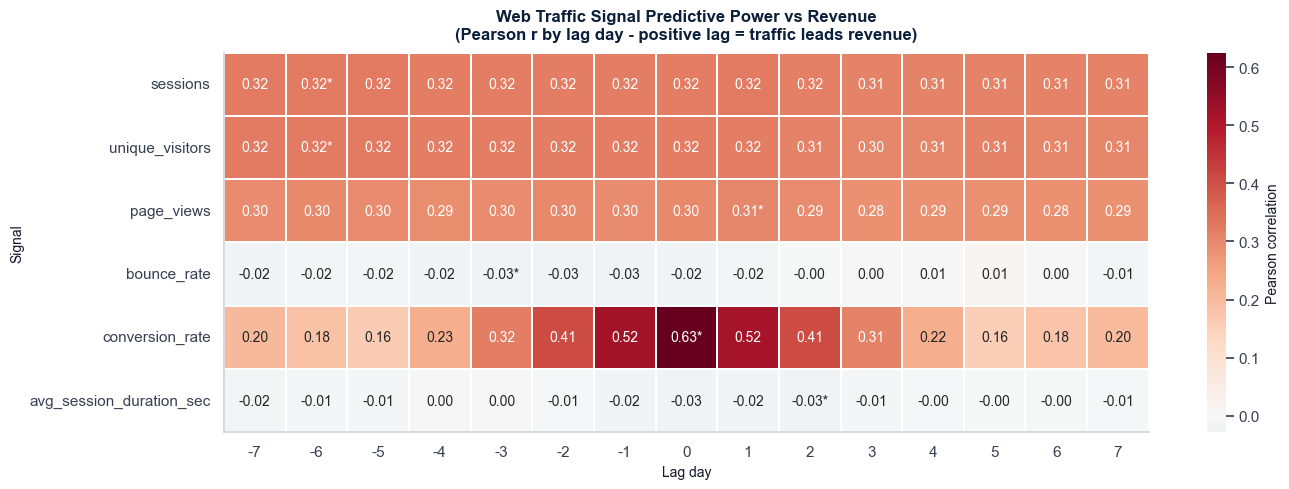

In [20]:
# Block 3 - Cell 3: Multi-signal predictive power heatmap
heat_src = signal_corr_df[signal_corr_df['lag_days'].between(-7, 7)].copy()
heat_pivot = heat_src.pivot(index='signal', columns='lag_days', values='corr').reindex(signal_cols)

annot_df = heat_pivot.copy().astype(object)
for sig in heat_pivot.index:
    row = heat_pivot.loc[sig]
    if row.notna().sum() == 0:
        continue
    max_lag = row.abs().idxmax()
    for lag in heat_pivot.columns:
        val = heat_pivot.loc[sig, lag]
        if pd.isna(val):
            annot_df.loc[sig, lag] = ''
        else:
            star = '*' if lag == max_lag else ''
            annot_df.loc[sig, lag] = f'{val:.2f}{star}'

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(
    heat_pivot,
    cmap='RdBu_r',
    center=0,
    annot=annot_df,
    fmt='',
    linewidths=0.25,
    linecolor='white',
    cbar_kws={'label': 'Pearson correlation'},
    ax=ax,
 )

style_axis(
    ax,
    'Web Traffic Signal Predictive Power vs Revenue\n(Pearson r by lag day - positive lag = traffic leads revenue)',
    'Lag day',
    'Signal',
)
ax.set_xticklabels([str(c) for c in heat_pivot.columns], rotation=0)
ax.set_yticklabels(heat_pivot.index, rotation=0)

plt.tight_layout()
display(fig)
plt.close(fig)

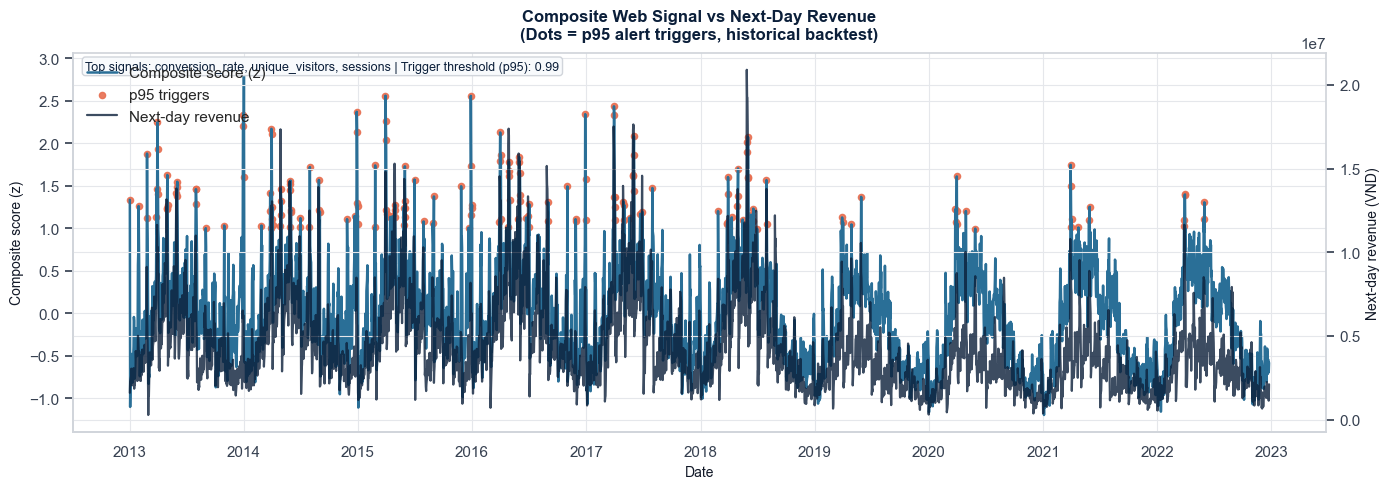

In [21]:
# Block 3 - Cell 4: Composite signal backtest
top3 = multi_signal_df.sort_values('R2', ascending=False).head(3).copy()
weights = top3['best_corr'].abs().values
weights = weights / weights.sum() if weights.sum() > 0 else np.array([1 / 3, 1 / 3, 1 / 3])

composite_df = signal_base_df[['date', 'revenue']].copy()
composite_df['date'] = pd.to_datetime(composite_df['date'])

for i, row in enumerate(top3.itertuples(index=False), start=1):
    sig = row.signal
    lag = int(row.best_lag)
    shifted = signal_base_df[sig].shift(lag)
    z = (shifted - shifted.mean()) / shifted.std(ddof=0)
    composite_df[f'z_{sig}'] = z
    composite_df[f'w_{sig}'] = weights[i - 1]

z_cols = [c for c in composite_df.columns if c.startswith('z_')]
w_cols = [c for c in composite_df.columns if c.startswith('w_')]
composite_df['composite_score'] = 0.0
for z_col, w_col in zip(z_cols, w_cols):
    composite_df['composite_score'] += composite_df[z_col] * composite_df[w_col]

composite_df['next_day_revenue'] = composite_df['revenue'].shift(-1)
composite_df = composite_df.dropna(subset=['composite_score', 'next_day_revenue']).reset_index(drop=True)

assert len(composite_df) > 0, 'Query tra ve empty DataFrame - kiem tra lai join conditions'
assert (composite_df.isnull().sum().sum() / max(composite_df.size, 1)) < 0.3, 'Qua nhieu null values - kiem tra lai logic'

trigger_threshold = composite_df['composite_score'].quantile(0.95)
trigger_df = composite_df[composite_df['composite_score'] > trigger_threshold].copy()
top_signal_list = ', '.join(top3['signal'].tolist())

fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()

ax1.plot(composite_df['date'], composite_df['composite_score'], color=TEAL, linewidth=1.8, label='Composite score (z)')
ax2.plot(composite_df['date'], composite_df['next_day_revenue'], color=NAVY, linewidth=1.6, alpha=0.8, label='Next-day revenue')
ax1.scatter(trigger_df['date'], trigger_df['composite_score'], color=CORAL, s=20, alpha=0.9, label='p95 triggers')

style_axis(
    ax1,
    'Composite Web Signal vs Next-Day Revenue\n(Dots = p95 alert triggers, historical backtest)',
    'Date',
    'Composite score (z)',
)
ax2.set_ylabel('Next-day revenue (VND)')

h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, frameon=False, loc='upper left')
ax1.text(
    0.01, 0.98,
    f'Top signals: {top_signal_list} | Trigger threshold (p95): {trigger_threshold:.2f}',
    transform=ax1.transAxes,
    ha='left', va='top',
    fontsize=9, color=NAVY,
    bbox=dict(boxstyle='round,pad=0.25', facecolor=LIGHT_BG, edgecolor='#D1D5DB'),
)

plt.tight_layout()
display(fig)
plt.close(fig)

In [22]:
# Block 3 - Cell 5: Pilot Design Box
insight_pilot = f"""
<div style='border-left: 6px solid {CORAL}; background:{LIGHT_BG}; padding: 12px 14px; margin: 8px 0;'>
<b>Business Insight - Predictive Hardening & Pilot Design</b><br>
- Sessions signal don le la muc vua (r~0.32) nen chua du de deploy rule van hanh tren toan he thong.<br>
- Multi-signal cho thay top 3 signal co predictive power tot nhat la: <b>{', '.join(top3['signal'].tolist())}</b>.<br>
- Composite signal duoc dung de tao trigger p95, giup giam false alarm so voi dung 1 bien sessions.<br>
<br>
<b>PILOT DESIGN - 8 tuan:</b><br>
- Treatment: kich hoat nhan su kho khi composite_score > p95.<br>
- Control: tuan xen ke khong kich hoat.<br>
- Primary KPI: late_delivery_rate (target giam >=15%).<br>
- Secondary KPI: stockout incidents tren trigger days.<br>
- Statistical criterion: p-value < 0.05 (two-sample t-test tren late_delivery_rate).<br>
- Go/No-Go: dat KPI + significance thi scale, nguoc lai reassess signal model.
</div>
"""
display(Markdown(insight_pilot))


<div style='border-left: 6px solid #E76F51; background:#F8FAFC; padding: 12px 14px; margin: 8px 0;'>
<b>Business Insight - Predictive Hardening & Pilot Design</b><br>
- Sessions signal don le la muc vua (r~0.32) nen chua du de deploy rule van hanh tren toan he thong.<br>
- Multi-signal cho thay top 3 signal co predictive power tot nhat la: <b>conversion_rate, unique_visitors, sessions</b>.<br>
- Composite signal duoc dung de tao trigger p95, giup giam false alarm so voi dung 1 bien sessions.<br>
<br>
<b>PILOT DESIGN - 8 tuan:</b><br>
- Treatment: kich hoat nhan su kho khi composite_score > p95.<br>
- Control: tuan xen ke khong kich hoat.<br>
- Primary KPI: late_delivery_rate (target giam >=15%).<br>
- Secondary KPI: stockout incidents tren trigger days.<br>
- Statistical criterion: p-value < 0.05 (two-sample t-test tren late_delivery_rate).<br>
- Go/No-Go: dat KPI + significance thi scale, nguoc lai reassess signal model.
</div>


---

## Level 4 Extension - Reviews x Returns: Quality Leakage Quantification

**Muc tieu:**
Noi ket review signal voi return behavior de xac dinh category dang 'rating cao nhung return cao' (quality leakage),
tu do uu tien corrective action voi impact tai chinh dinh luong.

In [23]:
# Block 4 - Cell 2: Reviews x returns base prep
oi_cols = con.execute('SELECT * FROM v_order_items_dedup LIMIT 1').df().columns.str.lower().tolist()

if 'revenue' in oi_cols:
    revenue_expr = 'oi.revenue'
elif 'net_revenue' in oi_cols:
    revenue_expr = 'oi.net_revenue'
else:
    revenue_expr = 'oi.quantity * oi.unit_price - COALESCE(oi.discount_amount, 0)'

if 'gross_profit' in oi_cols:
    gp_expr = 'oi.gross_profit'
else:
    gp_expr = f'({revenue_expr} - oi.quantity * p.cogs)'

reviews_returns_df = con.execute(f'''
SELECT
    oi.order_id,
    oi.product_id,
    oi.quantity,
    {revenue_expr} AS line_revenue,
    {gp_expr} AS line_gross_profit,
    p.product_name,
    p.category,
    r.rating,
    CASE WHEN ret.return_id IS NOT NULL THEN 1 ELSE 0 END AS is_returned,
    ret.return_reason,
    ret.refund_amount
FROM v_order_items_dedup oi
LEFT JOIN products p
    ON oi.product_id = p.product_id
LEFT JOIN reviews r
    ON oi.order_id = r.order_id
   AND oi.product_id = r.product_id
LEFT JOIN returns ret
    ON oi.order_id = ret.order_id
   AND oi.product_id = ret.product_id
''').df()

assert len(reviews_returns_df) > 0, 'Query tra ve empty DataFrame - kiem tra lai join conditions'
assert (reviews_returns_df.isnull().sum().sum() / max(reviews_returns_df.size, 1)) < 0.3, 'Qua nhieu null values - kiem tra lai logic'

category_kpi_df = (
    reviews_returns_df
    .groupby('category', dropna=False)
    .agg(
        avg_rating=('rating', 'mean'),
        return_rate=('is_returned', 'mean'),
        total_units=('quantity', 'sum'),
        total_lines=('order_id', 'count'),
        reviewed_lines=('rating', lambda s: s.notna().sum()),
        total_refund=('refund_amount', 'sum'),
    )
    .reset_index()
    .sort_values('total_units', ascending=False)
    .reset_index(drop=True)
)
category_kpi_df['total_refund'] = category_kpi_df['total_refund'].fillna(0)

valid_category_df = category_kpi_df[category_kpi_df['reviewed_lines'] >= 30].copy()
overall_rating = float(valid_category_df['avg_rating'].mean()) if len(valid_category_df) > 0 else float('nan')
overall_return_rate = float(valid_category_df['return_rate'].mean()) if len(valid_category_df) > 0 else float('nan')

paradox_df = valid_category_df[
    (valid_category_df['avg_rating'] >= overall_rating)
    & (valid_category_df['return_rate'] >= overall_return_rate)
] .copy()

avg_refund_per_return = reviews_returns_df.loc[reviews_returns_df['is_returned'] == 1, 'refund_amount'].mean()
if pd.isna(avg_refund_per_return):
    avg_refund_per_return = 0.0

paradox_df['excess_returns'] = np.maximum(0, (paradox_df['return_rate'] - overall_return_rate) * paradox_df['total_lines'])
avoidable_refund_vnd = float((paradox_df['excess_returns'].sum()) * avg_refund_per_return)

display(valid_category_df.head(10))

,category,avg_rating,return_rate,total_units,total_lines,reviewed_lines,total_refund
0,Streetwear,3.939416,0.055398,1768840,393535,62706,4.067659e+08
1,Outdoor,3.933891,0.056618,1170000,259986,41265,7.871751e+07
2,GenZ,3.922825,0.057264,166853,37161,5792,1.114977e+07
3,Casual,3.923219,0.053937,107469,23991,3790,1.402709e+07


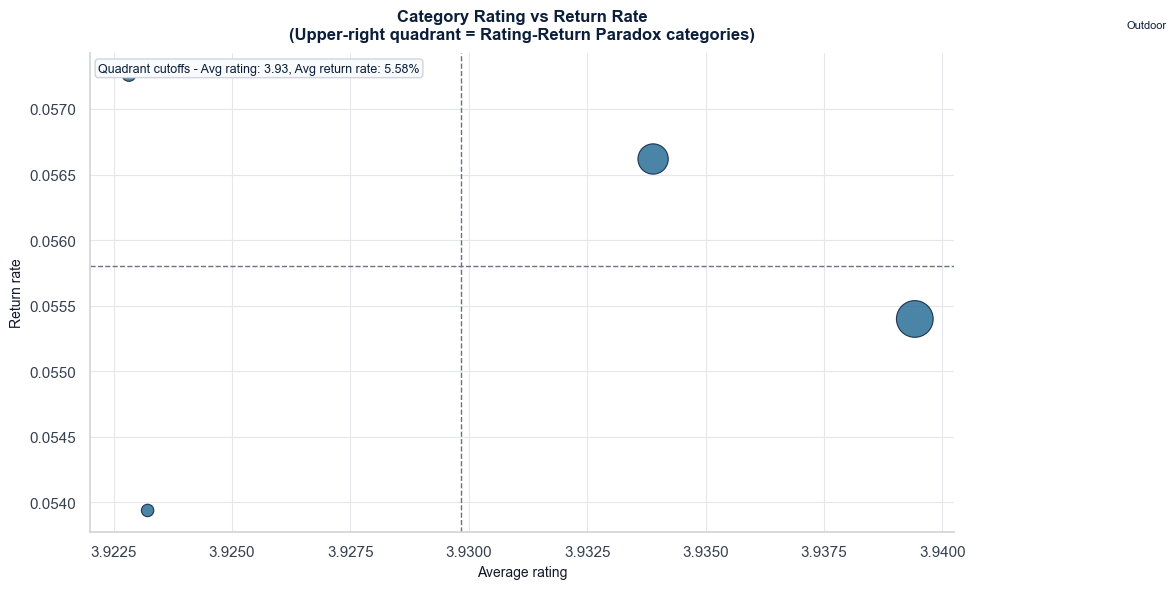

In [24]:
# Block 4 - Cell 3: Rating-return paradox scatter by category
plot_df = valid_category_df.dropna(subset=['avg_rating', 'return_rate']).copy()

fig, ax = plt.subplots(figsize=(12, 6))
sns.scatterplot(
    data=plot_df,
    x='avg_rating',
    y='return_rate',
    size='total_units',
    sizes=(80, 700),
    alpha=0.85,
    color=TEAL,
    edgecolor=NAVY,
    linewidth=0.8,
    legend=False,
    ax=ax,
 )

ax.axvline(overall_rating, color=GRAY, linestyle='--', linewidth=1.0)
ax.axhline(overall_return_rate, color=GRAY, linestyle='--', linewidth=1.0)

for row in paradox_df.nlargest(5, 'return_rate').itertuples(index=False):
    ax.text(
        row.avg_rating + 0.01,
        row.return_rate + 0.001,
        str(row.category),
        fontsize=8,
        color=NAVY,
    )

style_axis(
    ax,
    'Category Rating vs Return Rate\n(Upper-right quadrant = Rating-Return Paradox categories)',
    'Average rating',
    'Return rate',
)
ax.text(
    0.01, 0.98,
    f'Quadrant cutoffs - Avg rating: {overall_rating:.2f}, Avg return rate: {overall_return_rate:.2%}',
    transform=ax.transAxes,
    ha='left', va='top',
    fontsize=9, color=NAVY,
    bbox=dict(boxstyle='round,pad=0.25', facecolor=LIGHT_BG, edgecolor='#D1D5DB'),
)

plt.tight_layout()
display(fig)
plt.close(fig)

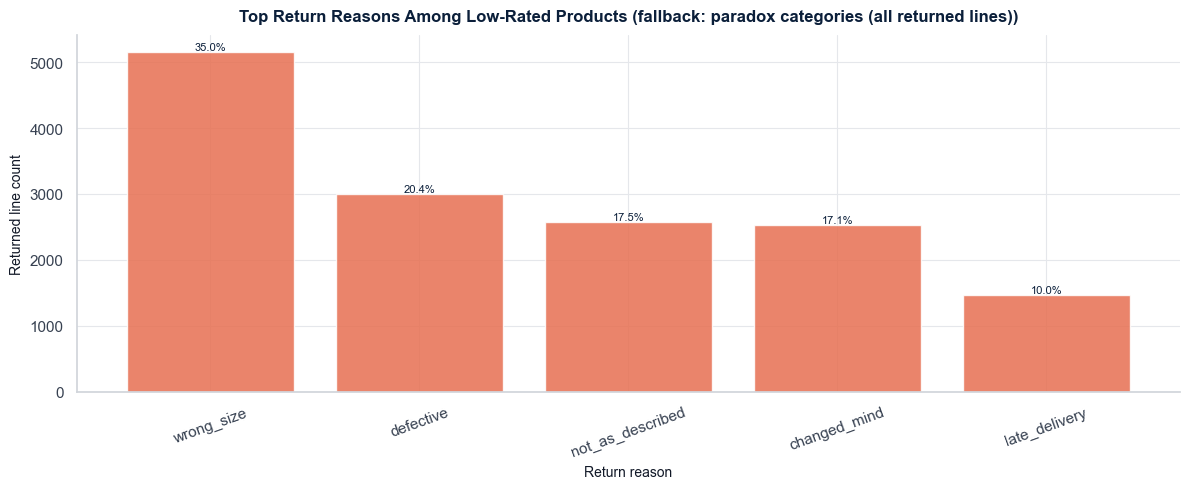

In [29]:
# Block 4 - Cell 4: Return reason breakdown for low-rated products
low_rated_returns_df = reviews_returns_df[
    (reviews_returns_df['rating'].notna())
    & (reviews_returns_df['rating'] <= 3)
    & (reviews_returns_df['is_returned'] == 1)
    & (reviews_returns_df['return_reason'].notna())
] .copy()
low_rating_bucket_label = 'rating <= 3'

if len(low_rated_returns_df) == 0:
    fallback_threshold = float(reviews_returns_df['rating'].dropna().quantile(0.20))
    low_rated_returns_df = reviews_returns_df[
        (reviews_returns_df['rating'].notna())
        & (reviews_returns_df['rating'] <= fallback_threshold)
        & (reviews_returns_df['is_returned'] == 1)
        & (reviews_returns_df['return_reason'].notna())
    ].copy()
    low_rating_bucket_label = f'bottom 20% rating bucket (<= {fallback_threshold:.2f})'

if len(low_rated_returns_df) == 0 and len(paradox_df) > 0:
    low_rated_returns_df = reviews_returns_df[
        (reviews_returns_df['category'].isin(paradox_df['category']))
        & (reviews_returns_df['is_returned'] == 1)
        & (reviews_returns_df['return_reason'].notna())
    ].copy()
    low_rating_bucket_label = 'fallback: paradox categories (all returned lines)'

reason_df = (
    low_rated_returns_df
    .groupby('return_reason', dropna=False)
    .agg(return_lines=('order_id', 'count'))
    .reset_index()
    .sort_values('return_lines', ascending=False)
    .head(8)
)

fig, ax = plt.subplots(figsize=(12, 5))
if len(reason_df) == 0:
    style_axis(
        ax,
        'Top Return Reasons Among Low-Rated Products\n(No returned lines in selected low-rating bucket)',
        'Return reason',
        'Returned line count',
    )
    ax.text(0.5, 0.5, 'Khong co du lieu return_reason trong low-rating bucket', ha='center', va='center', transform=ax.transAxes, color=NAVY)
else:
    reason_df['pct'] = reason_df['return_lines'] / reason_df['return_lines'].sum()
    bars = ax.bar(reason_df['return_reason'], reason_df['return_lines'], color=CORAL, alpha=0.85, edgecolor='white')

    for b, pct in zip(bars, reason_df['pct']):
        ax.text(
            b.get_x() + b.get_width() / 2,
            b.get_height(),
            f'{pct:.1%}',
            ha='center',
            va='bottom',
            fontsize=8,
            color=NAVY,
        )

    style_axis(
        ax,
        f'Top Return Reasons Among Low-Rated Products ({low_rating_bucket_label})',
        'Return reason',
        'Returned line count',
    )
    ax.tick_params(axis='x', rotation=20)

plt.tight_layout()
display(fig)
plt.close(fig)

In [31]:
# Block 4 - Cell 5: Business insight box (quality leakage to refund impact)
rating_return_corr = float(plot_df['avg_rating'].corr(plot_df['return_rate'])) if len(plot_df) > 1 else float('nan')
paradox_categories = paradox_df['category'].astype(str).head(4).tolist()
paradox_text = ', '.join(paradox_categories) if len(paradox_categories) > 0 else 'Khong co category nghich ly ro rang'

top_reason_text = 'N/A'
top_reason_pct = 0.0
if len(reason_df) > 0:
    reason_df_sorted = reason_df.sort_values('return_lines', ascending=False).copy()
    top_reason_text = str(reason_df_sorted.iloc[0]['return_reason'])
    if reason_df_sorted['return_lines'].sum() > 0:
        top_reason_pct = float(reason_df_sorted.iloc[0]['return_lines'] / reason_df_sorted['return_lines'].sum())

if avoidable_refund_vnd >= 1e9:
    avoidable_refund_text = f'{avoidable_refund_vnd / 1e9:.2f} ty VND'
else:
    avoidable_refund_text = f'{avoidable_refund_vnd / 1e6:.1f} trieu VND'

insight_quality = f"""
<div style='border-left: 6px solid {CORAL}; background:{LIGHT_BG}; padding: 12px 14px; margin: 8px 0;'>
<b>Business Insight - Quality Leakage Detection</b><br>
- Tuong quan rating-return theo category: <b>{rating_return_corr:.2f}</b> (am la tot, duong la canh bao nghich ly).<br>
- Category nghich ly (rating >= avg va return_rate >= avg): <b>{paradox_text}</b>.<br>
- Bucket phan tich low-rated: <b>{low_rating_bucket_label}</b>.<br>
- Top return reason trong bucket tren: <b>{top_reason_text}</b> ({top_reason_pct:.1%}).<br>
- Uoc tinh avoidable refund neu paradox categories dua return_rate ve benchmark trung binh: <b>{avoidable_refund_text}</b>.<br>
<br>
<b>Prescriptive Action:</b> uu tien root-cause review cho paradox categories (QC at source, packaging stress test, PDP content),
gan owner theo return_reason top-1 va theo doi giam return_rate theo sprint 2 tuan.
</div>
"""
display(Markdown(insight_quality))


<div style='border-left: 6px solid #E76F51; background:#F8FAFC; padding: 12px 14px; margin: 8px 0;'>
<b>Business Insight - Quality Leakage Detection</b><br>
- Tuong quan rating-return theo category: <b>0.04</b> (am la tot, duong la canh bao nghich ly).<br>
- Category nghich ly (rating >= avg va return_rate >= avg): <b>Outdoor</b>.<br>
- Bucket phan tich low-rated: <b>fallback: paradox categories (all returned lines)</b>.<br>
- Top return reason trong bucket tren: <b>wrong_size</b> (35.0%).<br>
- Uoc tinh avoidable refund neu paradox categories dua return_rate ve benchmark trung binh: <b>2.7 trieu VND</b>.<br>
<br>
<b>Prescriptive Action:</b> uu tien root-cause review cho paradox categories (QC at source, packaging stress test, PDP content),
gan owner theo return_reason top-1 va theo doi giam return_rate theo sprint 2 tuan.
</div>


In [32]:
# Final verification - extension blocks healthcheck
checks = [
    ('Block 1 - Customer CLV/RFM ready', 'rfm_df' in globals() and len(rfm_df) > 0),
    ('Block 1 - Cohort retention ready', 'cohort_heatmap_df' in globals() and cohort_heatmap_df.shape[0] > 0),
    ('Block 2 - Tet quantification ready', 'tet_effect_df' in globals() and len(tet_effect_df) > 0),
    ('Block 2 - COVID counterfactual ready', 'full_df' in globals() and 'counterfactual_revenue' in full_df.columns),
    ('Block 3 - Multi-signal model ready', 'multi_signal_df' in globals() and len(multi_signal_df) > 0),
    ('Block 3 - Composite trigger ready', 'composite_df' in globals() and len(composite_df) > 0),
    ('Block 4 - Reviews x returns ready', 'reviews_returns_df' in globals() and len(reviews_returns_df) > 0),
    ('Block 4 - Quality leakage insight ready', 'paradox_df' in globals()),
]

verification_df = pd.DataFrame(checks, columns=['check', 'status'])
verification_df['status'] = verification_df['status'].map({True: 'PASS', False: 'FAIL'})

display(verification_df)
assert (verification_df['status'] == 'PASS').all(), 'Con buoc extension chua pass - vui long kiem tra cell phia tren'

,check,status
0,Block 1 - Customer CLV/RFM ready,PASS
1,Block 1 - Cohort retention ready,PASS
2,Block 2 - Tet quantification ready,PASS
3,Block 2 - COVID counterfactual ready,PASS
4,Block 3 - Multi-signal model ready,PASS
5,Block 3 - Composite trigger ready,PASS
6,Block 4 - Reviews x returns ready,PASS
7,Block 4 - Quality leakage insight ready,PASS
